# Analyze Ball on Incline data
Use this notebook to quickly test whether your ball on incline data makes sense!

In [1]:
# Imports
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import pandas as pd
import math
from scipy.signal import find_peaks, peak_widths
from statistics import mean
from iminuit import Minuit
from iminuit import cost
from scipy import stats
import matplotlib as mpl


try:
    from scipy.stats import chi2
    _SCIPY = True
except Exception:
    _SCIPY = False


In [2]:
# Weigthed mean and error
def weighted_mean(value, error) :
    assert(len(value) == len(error))
    wmean = np.sum((value/(error**2)) / np.sum(1.0/(error**2)))
    wmean_err = error = np.sqrt(1.0/np.sum(1.0/np.square(error)))
    return wmean, wmean_err

## Ball diameter

In [3]:
# all lengths in meter
ball_s = np.array([10.0, 9.9, 9.9, 10.0, 9.8])/1000         # ball 1
ball_s_err = np.array([0.1, 0.1, 0.1, 0.1, 0.1])/1000

ball_m = np.array([11.9, 11.8, 11.9, 11.9, 11.9])/1000      # ball 3
ball_m_err = np.array([0.1, 0.1, 0.1, 0.1, 0.1])/1000

ball_l = np.array([14.9, 14.9, 14.9, 14.9, 14.8])/1000      # ball 2
ball_l_err = np.array([0.1, 0.1, 0.1, 0.1, 0.1])/1000

In [4]:
# Weigthed mean and error
ball_s_weighted, ball_s_weighted_err = weighted_mean(ball_s, ball_s_err)
ball_m_weighted, ball_m_weighted_err = weighted_mean(ball_m, ball_m_err)
ball_l_weighted, ball_l_weighted_err = weighted_mean(ball_l, ball_l_err)

print("weighted ball s [mm] = ",ball_s_weighted * 1000)
print("weighted ball s error [mm] = ", ball_s_weighted_err * 1000)

print("\nweighted ball m [mm] = ",ball_m_weighted * 1000)
print("weighted ball m error [mm] = ", ball_m_weighted_err * 1000)

print("\nweighted ball l [mm] = ",ball_l_weighted * 1000)
print("weighted ball l error [mm] = ", ball_l_weighted_err * 1000)

weighted ball s [mm] =  9.920000000000002
weighted ball s error [mm] =  0.044721359549995794

weighted ball m [mm] =  11.880000000000003
weighted ball m error [mm] =  0.044721359549995794

weighted ball l [mm] =  14.88
weighted ball l error [mm] =  0.044721359549995794


In [5]:
# Chi2
chi2_ball_s = np.sum((ball_s - ball_s_weighted)**2/ball_s_err**2)
chi2_prob_ball_s = stats.chi2.sf(chi2_ball_s, len(ball_s)-1)
dof_ball_s = len(ball_s)-1

chi2_ball_m = np.sum((ball_m - ball_m_weighted)**2/ball_m_err**2)
chi2_prob_ball_m = stats.chi2.sf(chi2_ball_m, len(ball_m)-1)
dof_ball_m = len(ball_m)-1

chi2_ball_l = np.sum((ball_l - ball_l_weighted)**2/ball_l_err**2)
chi2_prob_ball_l = stats.chi2.sf(chi2_ball_l, len(ball_l)-1)
dof_ball_l = len(ball_l)-1

print("chi2 small ball", chi2_ball_s)
print("chi2 prob small ball", chi2_prob_ball_s)
print("DOF small ball", dof_ball_s)

print("\nchi2 medium ball", chi2_ball_m)
print("chi2 prob medium ball", chi2_prob_ball_m)
print("DOF medium ball", dof_ball_m)

print("\nchi2 large ball", chi2_ball_l)
print("chi2 prob large ball", chi2_prob_ball_l)
print("DOF large ball", dof_ball_l)

chi2 small ball 2.799999999999966
chi2 prob small ball 0.5918327134598613
DOF small ball 4

chi2 medium ball 0.7999999999999902
chi2 prob medium ball 0.9384480644498964
DOF medium ball 4

chi2 large ball 0.7999999999999903
chi2 prob large ball 0.9384480644498964
DOF large ball 4


## Rail and gates

In [6]:
rail_distances = np.array([6.0, 5.8, 5.9, 5.8, 5.8])/1000
rail_distances_err = np.array([0.1, 0.1, 0.1, 0.1, 0.1])/1000

In [7]:
rail_distances_weighted, rail_distances_weighted_err = weighted_mean(rail_distances, rail_distances_err)
print("rail_distances_weighted [cm] = ", rail_distances_weighted * 100)
print("rail_distances_weighted error [cm] = ", rail_distances_weighted_err * 100)

rail_distances_weighted [cm] =  0.5860000000000001
rail_distances_weighted error [cm] =  0.00447213595499958


In [8]:
# Chi2
chi2_rail = np.sum((rail_distances - rail_distances_weighted)**2/rail_distances_err**2)
chi2_prob_rail = stats.chi2.sf(chi2_rail, len(rail_distances)-1)
dof_rail = len(rail_distances)-1

print("chi2 rail", chi2_rail)
print("chi2 prob rail", chi2_prob_rail)
print("DOF rail", dof_rail)

chi2 rail 3.2000000000000237
chi2 prob rail 0.5249309467861005
DOF rail 4


In [9]:
gate_position_1_initial = np.array([82.15, 82.17, 82.08, 82.15, 82.15])/100
gate_position_2_initial = np.array([67.15, 67.19, 67.16, 67.20, 67.15])/100
gate_position_3_initial = np.array([51.95, 51.91, 51.91, 51.65, 51.90])/100
gate_position_4_initial = np.array([37.05, 37.05, 37.01, 37.00, 37.05])/100
gate_position_5_initial = np.array([21.45, 21.41, 21.43, 21.45, 21.40])/100

gate_position_all = np.array([gate_position_1_initial, 
                              gate_position_2_initial,
                              gate_position_3_initial, 
                              gate_position_4_initial, 
                              gate_position_5_initial])

gate_position_err = np.array([0.15, 0.10, 0.10, 0.20, 0.10])/100

In [10]:
gate_position_weighted = np.array([])
gate_position_weighted_err = np.array([])

n_sets = len(gate_position_all)

for i in range(n_sets):
    gate_position_weighted = np.append(gate_position_weighted, weighted_mean(gate_position_all[i], gate_position_err)[0])
    gate_position_weighted_err = np.append(gate_position_weighted_err, weighted_mean(gate_position_all[i], gate_position_err)[1])

#gate_position_weighted_shifted
gate_position_weighted_shifted = -gate_position_weighted 

print("weighted gate positions [cm] = ",gate_position_weighted_shifted * 100)
print("weighted gate positions error [cm] = ", gate_position_weighted_err * 100)

weighted gate positions [cm] =  [-82.13646617 -67.16691729 -51.89451128 -37.03578947 -21.42022556]
weighted gate positions error [cm] =  [0.0520266 0.0520266 0.0520266 0.0520266 0.0520266]


In [11]:
# Chi2
chi2_gate_list = np.array([])
chi2_prob_gate_list = np.array([])
dof_gate_list = np.array([])

for i in range(len(gate_position_all)):
    chi2_gate = np.sum((gate_position_all [i] - gate_position_weighted [i])**2/gate_position_err**2)
    chi2_prob_gate = stats.chi2.sf(chi2_gate, len(gate_position_all[i])-1)
    dof_gate = len(gate_position_all[i])-1
    chi2_gate_list = np.append(chi2_gate_list, chi2_gate)
    chi2_prob_gate_list = np.append(chi2_prob_gate_list, chi2_prob_gate)
    dof_gate_list = np.append(dof_gate_list, dof_gate)

print("chi2 gates", chi2_gate_list)
print("chi2 prob gates", chi2_prob_gate_list)
print("DOF gates", dof_gate_list)

chi2 gates [0.46233083 0.12676692 1.6824812  0.14789474 0.1224812 ]
chi2 prob gates [0.97706295 0.99807416 0.79389742 0.99739701 0.99819962]
DOF gates [4. 4. 4. 4. 4.]


## Angels trig

In [12]:
distance_trig = np.array([88.79, 88.75, 88.76, 88.79, 88.78])/100
distance_trig_err = np.array([0.05, 0.05, 0.05, 0.10, 0.02])/100
height_trig = np.array([22.10, 22.08, 22.09, 22.10, 22.12])/100
height_trig_err = np.array([0.10, 0.01, 0.05, 0.05, 0.02])/100

def calc_angle_trig(height, height_err, length, length_err):
    angle = np.arctan(height / length)
    #Common factor
    factor = 1.0 / (1.0 + (height / length)**2)

    # Partial derivatives
    dtheta_dh = factor * (1.0 / length)
    dtheta_dl = factor * (-height / (length**2))

    # Error
    angle_error = np.sqrt((dtheta_dh * height_err)**2 + (dtheta_dl * length_err)**2)
    return np.degrees(angle), np.degrees(angle_error)

angle_trig, angle_trig_err = calc_angle_trig(height_trig, height_trig_err, distance_trig, distance_trig_err)

# Print in degrees
print("Angle [deg]:     ", angle_trig)
print("Angle err [deg] ", angle_trig_err)

angle_trig_overall_wmean, angle_trig_overall_werr = weighted_mean(angle_trig, angle_trig_err)
print("\nOverall:")
print(f"  weighted mean = {angle_trig_overall_wmean:.3f}° ± {angle_trig_overall_werr:.4f}°")


Angle [deg]:      [13.97701284 13.97090674 13.97547317 13.97701284 13.99067903]
Angle err [deg]  [0.06123377 0.00970332 0.03132029 0.03393889 0.01252447]

Overall:
  weighted mean = 13.978° ± 0.0072°


In [13]:
# Chi2
chi2_trig = np.sum((angle_trig - angle_trig_overall_wmean)**2/angle_trig_err**2)
chi2_prob_trig = stats.chi2.sf(chi2_trig, len(angle_trig)-1)
dof_trig = len(angle_trig)-1

print("chi2 trig", chi2_trig)
print("chi2 prob trig", chi2_prob_trig)
print("DOF trig", dof_trig)

chi2 trig 1.5666606886276673
chi2 prob trig 0.8147713574058609
DOF trig 4


## Angels goniometer

In [14]:
angle_goniometer_normal_a = 90-np.array([75.9, 75.9, 75.8, 75.9, 75.9])
angle_goniometer_normal_b = 90-np.array([76.2, 76.1, 76.3, 76.1, 76.1])
angle_goniometer_reverse_a = 90-np.array([76.2, 76.1, 76.3, 76.2, 76.1])
angle_goniometer_reverse_b = 90-np.array([75.9, 75.9, 75.9, 76.0, 75.9])
angle_goniometer_err = np.array([0.1, 0.1, 0.1, 0.1, 0.1])

# Compute weighted mean and error per set
sets = {
    "normal_a": angle_goniometer_normal_a,
    "normal_b": angle_goniometer_normal_b,
    "reverse_a": angle_goniometer_reverse_a,
    "reverse_b": angle_goniometer_reverse_b,
}

list_weighted_angle = np.array([])
list_weighted_angle_err = np.array([])

for name, arr in sets.items():
    wmean, werr = weighted_mean(arr, angle_goniometer_err)
    print(f"{name:>10}: weighted mean = {wmean:.3f}° ± {werr:.3f}°")
    list_weighted_angle = np.append(list_weighted_angle, wmean)
    list_weighted_angle_err = np.append(list_weighted_angle_err, werr)

# Overall (concatenate all points; same uncertainty 0.1° per point)

angle_goniometer_normal_wmean, angle_goniometer_normal_werr = weighted_mean(np.array([list_weighted_angle[0], list_weighted_angle[1]]), np.array([list_weighted_angle_err[0], list_weighted_angle_err[1]]))
angle_goniometer_reverse_wmean, angle_goniometer_reverse_werr = weighted_mean(np.array([list_weighted_angle[2], list_weighted_angle[3]]), np.array([list_weighted_angle_err[2], list_weighted_angle_err[3]]))
print("\nOverall:")
print(f" weighted mean normal = {angle_goniometer_normal_wmean:.3f}° ± {angle_goniometer_normal_werr:.3f}°")
print(f" weighted mean reverse = {angle_goniometer_reverse_wmean:.3f}° ± {angle_goniometer_reverse_werr:.3f}°")

  normal_a: weighted mean = 14.120° ± 0.045°
  normal_b: weighted mean = 13.840° ± 0.045°
 reverse_a: weighted mean = 13.820° ± 0.045°
 reverse_b: weighted mean = 14.080° ± 0.045°

Overall:
 weighted mean normal = 13.980° ± 0.032°
 weighted mean reverse = 13.950° ± 0.032°


In [15]:
# Chi2
chi2_gonio_normal_a = np.sum((angle_goniometer_normal_a - list_weighted_angle[0])**2/angle_goniometer_err**2)
chi2_prob_gonio_normal_a = stats.chi2.sf(chi2_gonio_normal_a, len(angle_goniometer_normal_a)-1)
dof_gonio_normal_a = len(angle_goniometer_normal_a)-1

print("chi2 gonio_normal a", chi2_gonio_normal_a)
print("chi2 prob gonio_normal a", chi2_prob_gonio_normal_a)
print("DOF gonio_normal a", dof_gonio_normal_a)

# Chi2
chi2_gonio_normal_b = np.sum((angle_goniometer_normal_b - list_weighted_angle[1])**2/angle_goniometer_err**2)
chi2_prob_gonio_normal_b = stats.chi2.sf(chi2_gonio_normal_b, len(angle_goniometer_normal_b)-1)
dof_gonio_normal_b = len(angle_goniometer_normal_b)-1

print("\nchi2 gonio_normal b", chi2_gonio_normal_b)
print("chi2 prob gonio_normal b", chi2_prob_gonio_normal_b)
print("DOF gonio_normal b", dof_gonio_normal_b)

chi2_gonio_reverse_a = np.sum((angle_goniometer_reverse_a - list_weighted_angle[2])**2/angle_goniometer_err**2)
chi2_prob_gonio_reverse_a = stats.chi2.sf(chi2_gonio_reverse_a, len(angle_goniometer_reverse_a)-1)
dof_gonio_reverse_a = len(angle_goniometer_reverse_a)-1

print("\nchi2 gonio_reverse a", chi2_gonio_reverse_a)
print("chi2 prob gonio_reverse a", chi2_prob_gonio_reverse_a)
print("DOF gonio_reverse a", dof_gonio_reverse_a)

# Chi2
chi2_gonio_reverse_b = np.sum((angle_goniometer_reverse_b - list_weighted_angle[3])**2/angle_goniometer_err**2)
chi2_prob_gonio_reverse_b = stats.chi2.sf(chi2_gonio_reverse_b, len(angle_goniometer_reverse_b)-1)
dof_gonio_reverse_b = len(angle_goniometer_reverse_b)-1

print("\nchi2 gonio_reverse b", chi2_gonio_reverse_b)
print("chi2 prob gonio_reverse b", chi2_prob_gonio_reverse_b)
print("DOF gonio_reverse b", dof_gonio_reverse_b)

chi2 gonio_normal a 0.8000000000001362
chi2 prob gonio_normal a 0.9384480644498767
DOF gonio_normal a 4

chi2 gonio_normal b 3.2000000000001467
chi2 prob gonio_normal b 0.5249309467860805
DOF gonio_normal b 4

chi2 gonio_reverse a 2.8000000000001357
chi2 prob gonio_reverse a 0.5918327134598322
DOF gonio_reverse a 4

chi2 gonio_reverse b 0.7999999999999089
chi2 prob gonio_reverse b 0.9384480644499072
DOF gonio_reverse b 4


## Reading the data

The function "read_csv(filename)" takes in a filename and returns numpy arrays with time and voltage.

In [16]:
def read_csv(filename):
    """Read CSV from Waveforms"""
    dat = np.genfromtxt(filename, delimiter=',', skip_header=13, names=True)
    time = dat['Time_s']
    voltage = dat['Channel_1_V']
    return time, voltage

def find_midpoints(time, voltage, show_plot=True):
    """Find timing of ball crossings"""
    
    # Write a function yourself, which identifies the peaks in the voltage,
    # and returns values for passing times and (possibly) their uncertainties
    # in it (but they are generally very small!).
    t_pass = [0.0, 0.1]
    t_pass_sigma = [0.0001, 0.00001]
    
    return t_pass, t_pass_sigma

Text(0, 0.5, 'Voltage (V)')

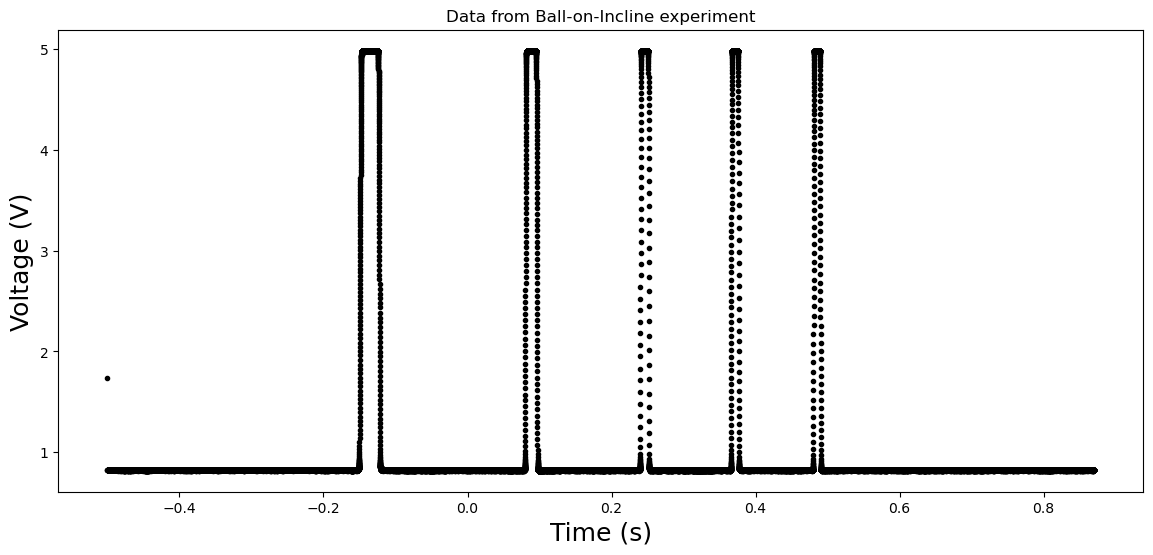

In [17]:
# looking at data from 50 kHz
filename = 'data_ball_50kHz/normal_big_1.csv'
time, voltage = read_csv(filename)
timepass, timepass_sig = find_midpoints(time, voltage)

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(time, voltage, 'k.', label='Measurements')
ax.set_title("Data from Ball-on-Incline experiment")
ax.set_xlabel("Time (s)", fontsize=18)
ax.set_ylabel("Voltage (V)", fontsize=18)

Five peak-start times (s):
-0.149974
0.080055
0.239979
0.365983
0.480272


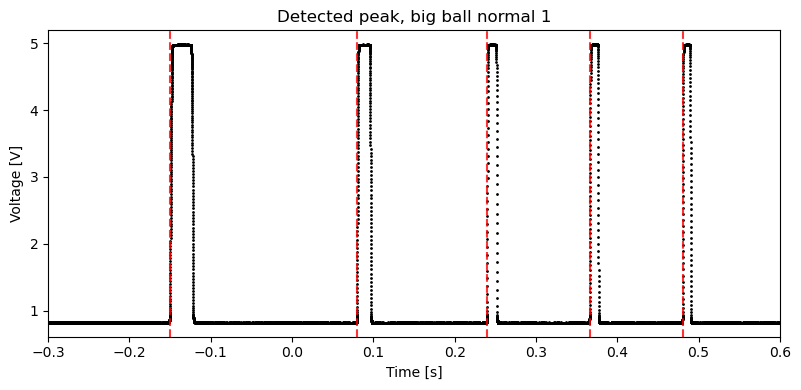

In [18]:
def find_peak_starts(time, voltage,
                     smooth_w=5,                 # moving-average window (samples)
                     min_height=None,            # absolute height threshold (V); auto if None
                     min_prom=0.5,               # peak prominence (V)
                     min_separation_s=0.05,      # min spacing between peaks (s)
                     rel_height=0.10):           # fraction of (peak - baseline) for "start"
    """
    Returns the first five start times where each peak begins to rise.
    'start' is defined as the first upward crossing of:
        baseline + rel_height * (peak_height - baseline).
    """

    time = np.asarray(time)
    voltage = np.asarray(voltage)

    # --- Ensure time is strictly increasing ---
    if not np.all(np.diff(time) > 0):
        idx = np.argsort(time)
        time = time[idx]
        voltage = voltage[idx]

    # --- Optional: light smoothing to reduce noise ---
    if smooth_w and smooth_w > 1:
        v_s = np.convolve(voltage, np.ones(smooth_w)/smooth_w, mode='same')
    else:
        v_s = voltage

    # --- Baseline and detection params ---
    baseline = np.median(v_s)
    if min_height is None:
        # Pick a height moderately above baseline so we avoid noise
        min_height = baseline + 0.2

    dt = np.median(np.diff(time))
    Fs = 1.0 / dt
    distance = max(1, int(min_separation_s * Fs))

    # --- Detect peaks ---
    peaks, props = find_peaks(v_s,
                              height=min_height,
                              prominence=min_prom,
                              distance=distance)
    if len(peaks) == 0:
        raise RuntimeError("No peaks detected. Try lowering min_height or min_prom.")

    # --- For each peak, walk left to find threshold up-crossing and interpolate crossing time ---
    start_times = []
    for p in peaks:
        peak_val = v_s[p]
        thr = baseline + rel_height * (peak_val - baseline)

        # Walk left until we find the last sample below 'thr'
        i = p
        while i > 0 and v_s[i] >= thr:
            i -= 1

        # Edge case: if the crossing happens before the signal starts
        if i == 0 and v_s[i] >= thr:
            # Couldn’t find a proper crossing; skip this peak
            continue

        # Linear interpolation between i (below thr) and i+1 (above thr)
        y0, y1 = v_s[i], v_s[i+1]
        x0, x1 = time[i], time[i+1]
        if y1 == y0:
            t_cross = x1
        else:
            t_cross = x0 + (thr - y0) * (x1 - x0) / (y1 - y0)

        start_times.append(t_cross)

    if len(start_times) < 5:
        # If fewer than 5 peaks found, just return what we have
        return np.array(sorted(start_times)), peaks

    # Return the first five in chronological order
    start_times = np.array(sorted(start_times))[:5]
    return start_times, peaks

five_starts, peaks = find_peak_starts(
    time, voltage,
    smooth_w=5,
    min_height=None,      # let the function choose baseline + 0.2 V
    min_prom=0.7,         # bump this up if you see extra detections
    min_separation_s=0.08,# match your visible spacing
    rel_height=0.08       # earlier start (5–10% is typical for sharp spikes)
)

print("Five peak-start times (s):")
for t in five_starts:
    print(f"{t:.6f}")

# Visual check
import matplotlib.pyplot as plt
plt.figure(figsize=(8,4))
plt.plot(time, voltage, ".k", markersize=2)
for t in five_starts:
    plt.axvline(t, color="r", ls="--", alpha=0.8)
plt.title("Detected peak, big ball normal 1")
plt.xlabel("Time [s]")
plt.ylabel("Voltage [V]")
plt.tight_layout()
plt.xlim(-0.3,0.6)
plt.show()



data_ball_50kHz/normal_big_1.csv — Five peak-start times (s):
  -0.149974
  0.080055
  0.239979
  0.365983
  0.480272

data_ball_50kHz/normal_big_2.csv — Five peak-start times (s):
  -0.275824
  -0.045042
  0.115060
  0.241123
  0.355430

data_ball_50kHz/normal_big_3.csv — Five peak-start times (s):
  -0.395875
  -0.165110
  -0.004968
  0.121151
  0.235222

data_ball_50kHz/normal_big_4.csv — Five peak-start times (s):
  0.068799
  0.298763
  0.458503
  0.584422
  0.698447

data_ball_50kHz/normal_big_5.csv — Five peak-start times (s):
  -0.213298
  0.015836
  0.175341
  0.301124
  0.415051


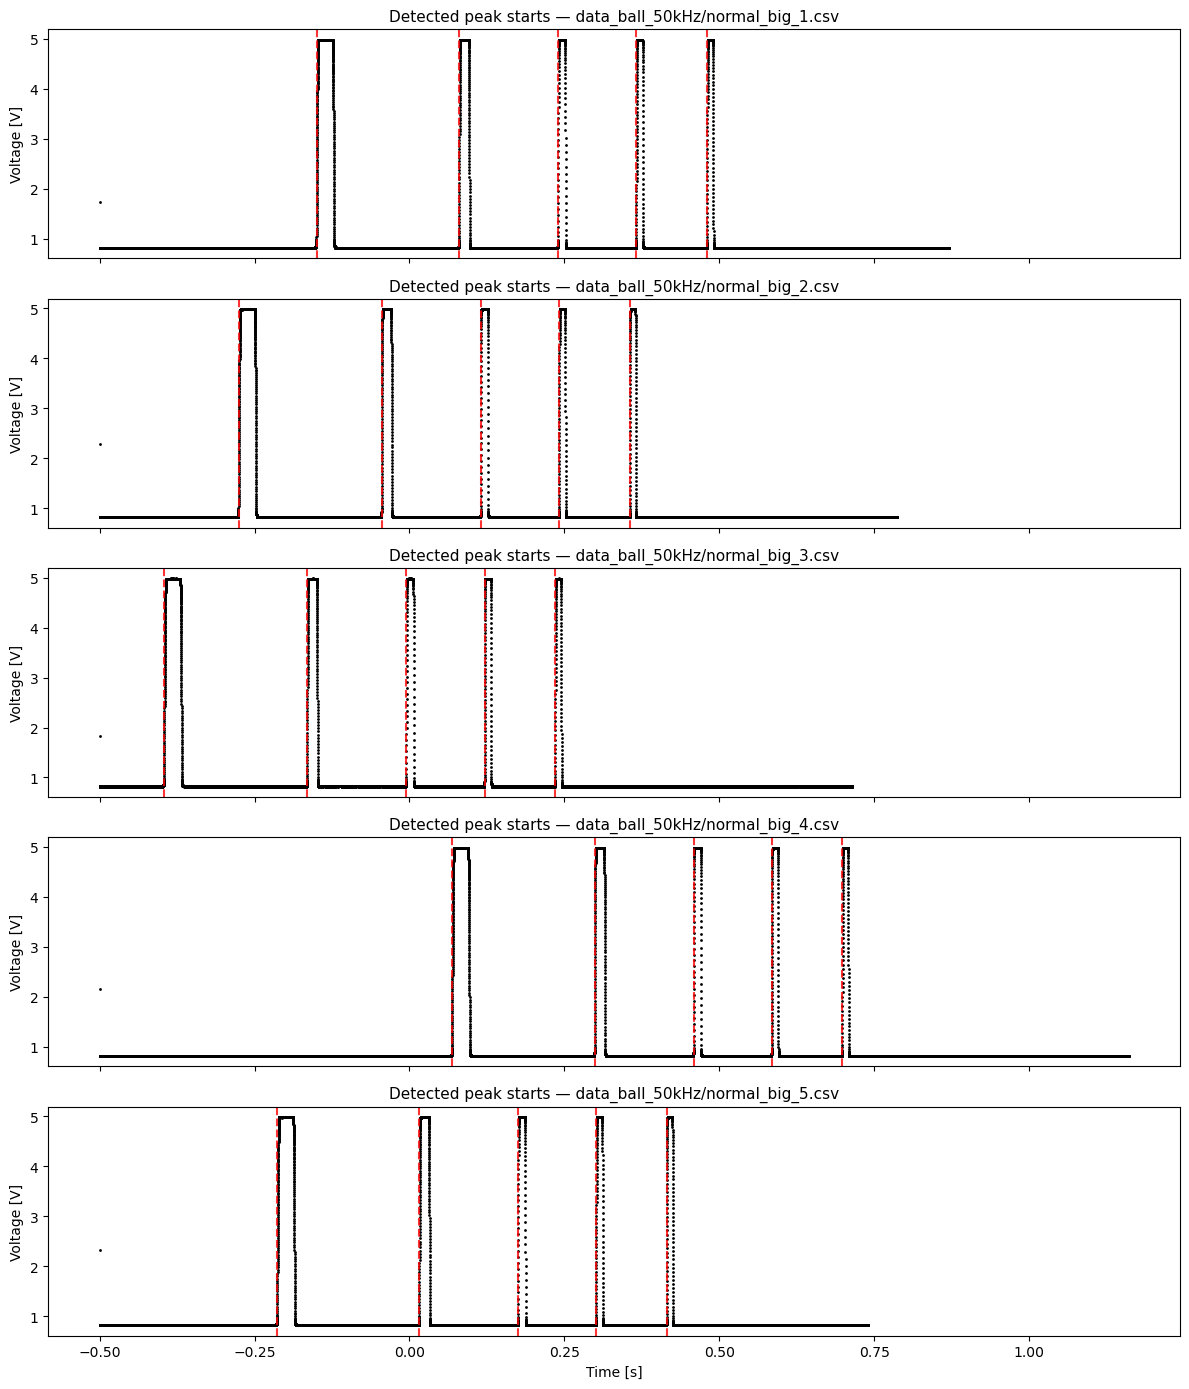

Original start times big ball, normal:
[[-0.14997387  0.08005532  0.23997932  0.36598339  0.48027183]
 [-0.27582359 -0.04504192  0.11506045  0.24112331  0.3554295 ]
 [-0.39587485 -0.16511037 -0.00496831  0.12115084  0.23522152]
 [ 0.06879895  0.29876295  0.45850329  0.58442194  0.69844707]
 [-0.21329783  0.01583588  0.17534078  0.3011236   0.41505101]]

Shifted start times (T1 = 0) big ball, normal:
[[0.         0.23002919 0.38995319 0.51595726 0.6302457 ]
 [0.         0.23078166 0.39088404 0.5169469  0.63125309]
 [0.         0.23076448 0.39090654 0.51702569 0.63109638]
 [0.         0.22996401 0.38970434 0.51562299 0.62964813]
 [0.         0.22913371 0.3886386  0.51442143 0.62834884]]


In [19]:
# ---------- Configure your 5 files ----------
filenames = [
    "data_ball_50kHz/normal_big_1.csv",
    "data_ball_50kHz/normal_big_2.csv",
    "data_ball_50kHz/normal_big_3.csv",
    "data_ball_50kHz/normal_big_4.csv",
    "data_ball_50kHz/normal_big_5.csv",
]

all_time_arrays = []   # list: each element is np.array of start times for one dataset

# Optional: params you may want to tune once for all datasets
SMOOTH_W = 5
MIN_PROM = 0.7          # raise if you see extra detections; lower if missing peaks
MIN_SEP_S = 0.08        # expected min spacing between spikes
REL_H = 0.08            # 5–10%: early start; 0.15–0.20: later start
MIN_HEIGHT = None       # or set e.g. baseline+0.3 if needed

# ---------- Load, compute, and plot ----------
n = len(filenames)
fig, axes = plt.subplots(nrows=n, ncols=1, figsize=(12, 2.8*n), sharex=True)

if n == 1:
    axes = [axes]  # make iterable if single

for ax, fname in zip(axes, filenames):
    # Load data
    time, voltage = read_csv(fname)

    # (Optional) shift time to start at zero across files
    # time = time - time.min()

    # Find starts
    starts, peaks = find_peak_starts(
        time, voltage,
        smooth_w=SMOOTH_W,
        min_height=MIN_HEIGHT,
        min_prom=MIN_PROM,
        min_separation_s=MIN_SEP_S,
        rel_height=REL_H
    )
    all_time_arrays = np.append(all_time_arrays, starts)
    # Print to console
    print(f"\n{fname} — Five peak-start times (s):")
    if len(starts) == 0:
        print("  No peaks detected. Try adjusting MIN_PROM / MIN_HEIGHT / REL_H.")
    else:
        for t in starts:
            print(f"  {t:.6f}")

    # Plot
    ax.plot(time, voltage, ".k", markersize=2)
    for t in starts:
        ax.axvline(t, color="r", ls="--", alpha=0.8)

    # Styling
    ax.set_title(f"Detected peak starts — {fname}", fontsize=11)
    ax.set_ylabel("Voltage [V]")

axes[-1].set_xlabel("Time [s]")
fig.tight_layout()
plt.show()

start_times_matrix = all_time_arrays.reshape(5, 5)   # rows = datasets (1..5), cols = T1..T5 
print("Original start times big ball, normal:")
print(start_times_matrix)

shifted_start_times_matrix_big_normal = start_times_matrix - start_times_matrix[:, [0]]
print("\nShifted start times (T1 = 0) big ball, normal:")
print(shifted_start_times_matrix_big_normal)


data_ball_50kHz/normal_medium_1.csv — Five peak-start times (s):
  -0.059586
  0.174833
  0.338081
  0.466954
  0.583674

data_ball_50kHz/normal_medium_2.csv — Five peak-start times (s):
  -0.218525
  0.015023
  0.177981
  0.306464
  0.423149

data_ball_50kHz/normal_medium_3.csv — Five peak-start times (s):
  -0.388776
  -0.155555
  0.007384
  0.135774
  0.252536

data_ball_50kHz/normal_medium_4.csv — Five peak-start times (s):
  -0.268031
  -0.035114
  0.127441
  0.255766
  0.371812

data_ball_50kHz/normal_medium_5.csv — Five peak-start times (s):
  -0.033205
  0.200154
  0.363167
  0.491624
  0.608225


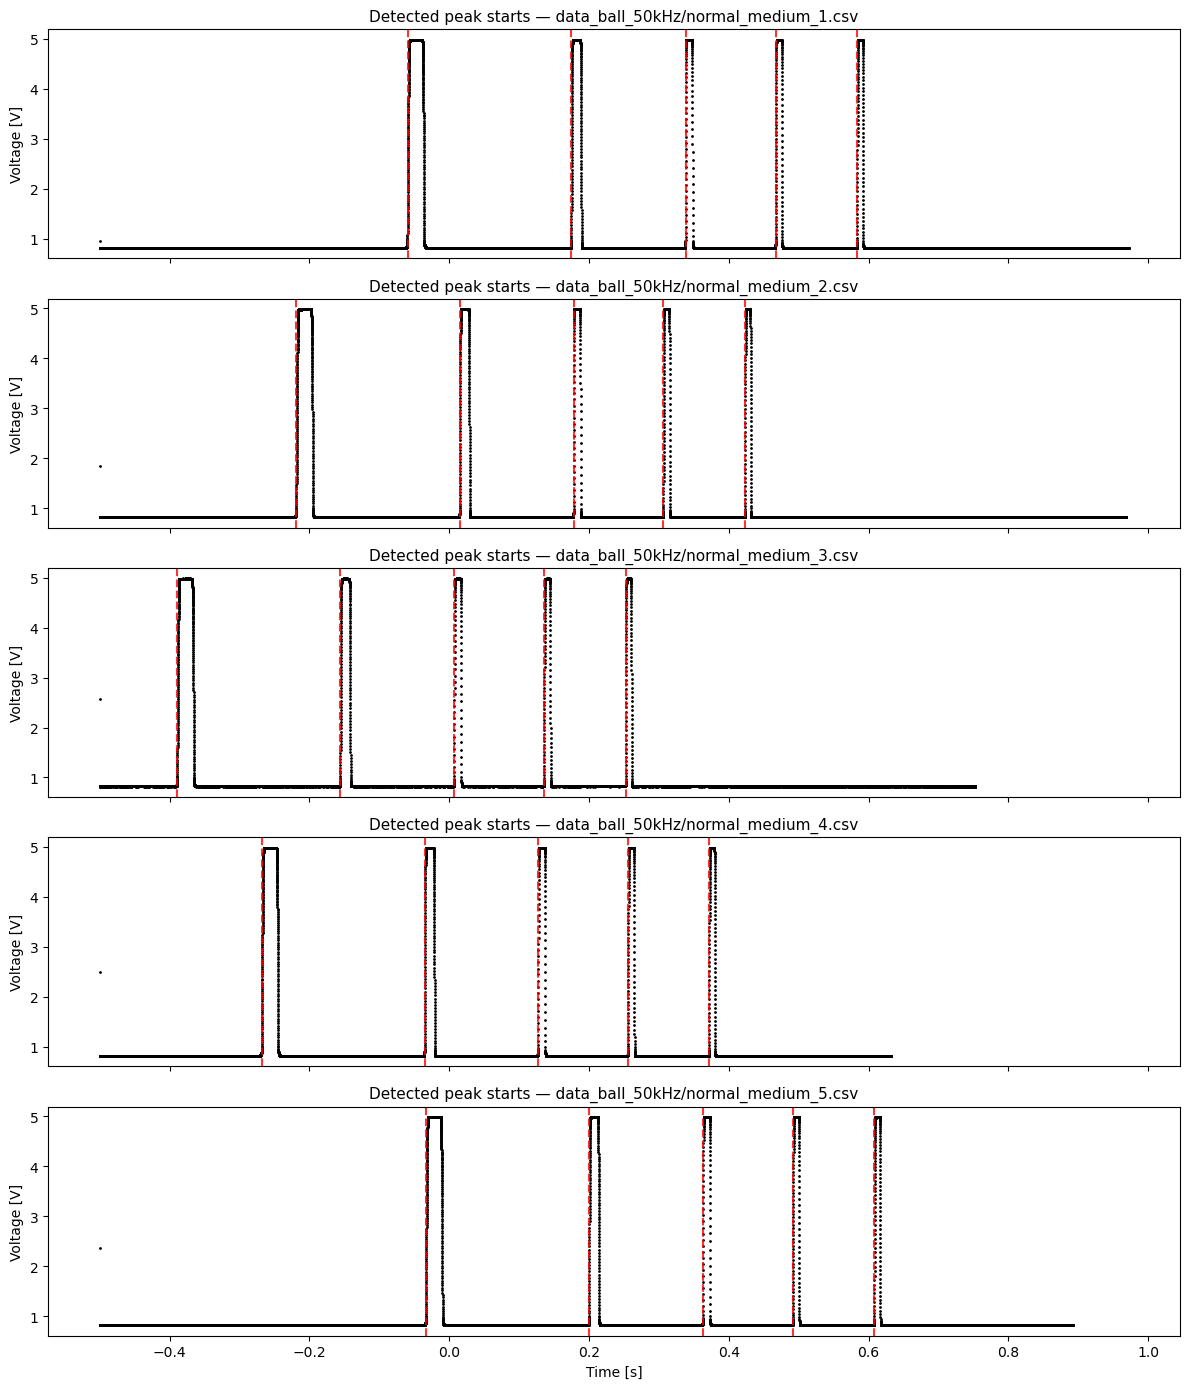

Original start times medium ball, normal:
[[-0.05958627  0.17483347  0.33808076  0.466954    0.58367426]
 [-0.21852513  0.01502269  0.17798062  0.30646393  0.42314891]
 [-0.38877599 -0.15555505  0.00738371  0.13577426  0.25253633]
 [-0.26803082 -0.03511385  0.12744139  0.25576647  0.37181223]
 [-0.03320489  0.20015383  0.36316681  0.49162417  0.60822475]]

Shifted start times (T1 = 0) medium ball, normal:
[[0.         0.23441974 0.39766703 0.52654026 0.64326053]
 [0.         0.23354781 0.39650575 0.52498905 0.64167403]
 [0.         0.23322094 0.3961597  0.52455024 0.64131232]
 [0.         0.23291698 0.39547221 0.5237973  0.63984305]
 [0.         0.23335871 0.3963717  0.52482906 0.64142964]]


In [20]:
# ---------- Configure your 5 files ----------
filenames = [
    "data_ball_50kHz/normal_medium_1.csv",
    "data_ball_50kHz/normal_medium_2.csv",
    "data_ball_50kHz/normal_medium_3.csv",
    "data_ball_50kHz/normal_medium_4.csv",
    "data_ball_50kHz/normal_medium_5.csv",
]

all_time_arrays = []   # list: each element is np.array of start times for one dataset

# Optional: params you may want to tune once for all datasets
SMOOTH_W = 5
MIN_PROM = 0.7          # raise if you see extra detections; lower if missing peaks
MIN_SEP_S = 0.08        # expected min spacing between spikes
REL_H = 0.08            # 5–10%: early start; 0.15–0.20: later start
MIN_HEIGHT = None       # or set e.g. baseline+0.3 if needed

# ---------- Load, compute, and plot ----------
n = len(filenames)
fig, axes = plt.subplots(nrows=n, ncols=1, figsize=(12, 2.8*n), sharex=True)

if n == 1:
    axes = [axes]  # make iterable if single

for ax, fname in zip(axes, filenames):
    # Load data
    time, voltage = read_csv(fname)

    # (Optional) shift time to start at zero across files
    # time = time - time.min()

    # Find starts
    starts, peaks = find_peak_starts(
        time, voltage,
        smooth_w=SMOOTH_W,
        min_height=MIN_HEIGHT,
        min_prom=MIN_PROM,
        min_separation_s=MIN_SEP_S,
        rel_height=REL_H
    )
    all_time_arrays = np.append(all_time_arrays, starts)
    # Print to console
    print(f"\n{fname} — Five peak-start times (s):")
    if len(starts) == 0:
        print("  No peaks detected. Try adjusting MIN_PROM / MIN_HEIGHT / REL_H.")
    else:
        for t in starts:
            print(f"  {t:.6f}")

    # Plot
    ax.plot(time, voltage, ".k", markersize=2)
    for t in starts:
        ax.axvline(t, color="r", ls="--", alpha=0.8)

    # Styling
    ax.set_title(f"Detected peak starts — {fname}", fontsize=11)
    ax.set_ylabel("Voltage [V]")

axes[-1].set_xlabel("Time [s]")
fig.tight_layout()
plt.show()

start_times_matrix = all_time_arrays.reshape(5, 5)   # rows = datasets (1..5), cols = T1..T5 
print("Original start times medium ball, normal:")
print(start_times_matrix)

shifted_start_times_matrix_medium_normal = start_times_matrix - start_times_matrix[:, [0]]
print("\nShifted start times (T1 = 0) medium ball, normal:")
print(shifted_start_times_matrix_medium_normal)


data_ball_50kHz/normal_small_1.csv — Five peak-start times (s):
  -0.085181
  0.162600
  0.333746
  0.467232
  0.590567

data_ball_50kHz/normal_small_2.csv — Five peak-start times (s):
  -0.221740
  0.026297
  0.200819
  0.337842
  0.462882

data_ball_50kHz/normal_small_3.csv — Five peak-start times (s):
  0.002991
  0.251424
  0.424860
  0.560106
  0.684841

data_ball_50kHz/normal_small_4.csv — Five peak-start times (s):
  -0.321698
  -0.074293
  0.097623
  0.232377
  0.354363

data_ball_50kHz/normal_small_5.csv — Five peak-start times (s):
  -0.044265
  0.199972
  0.371567
  0.505999
  0.629288


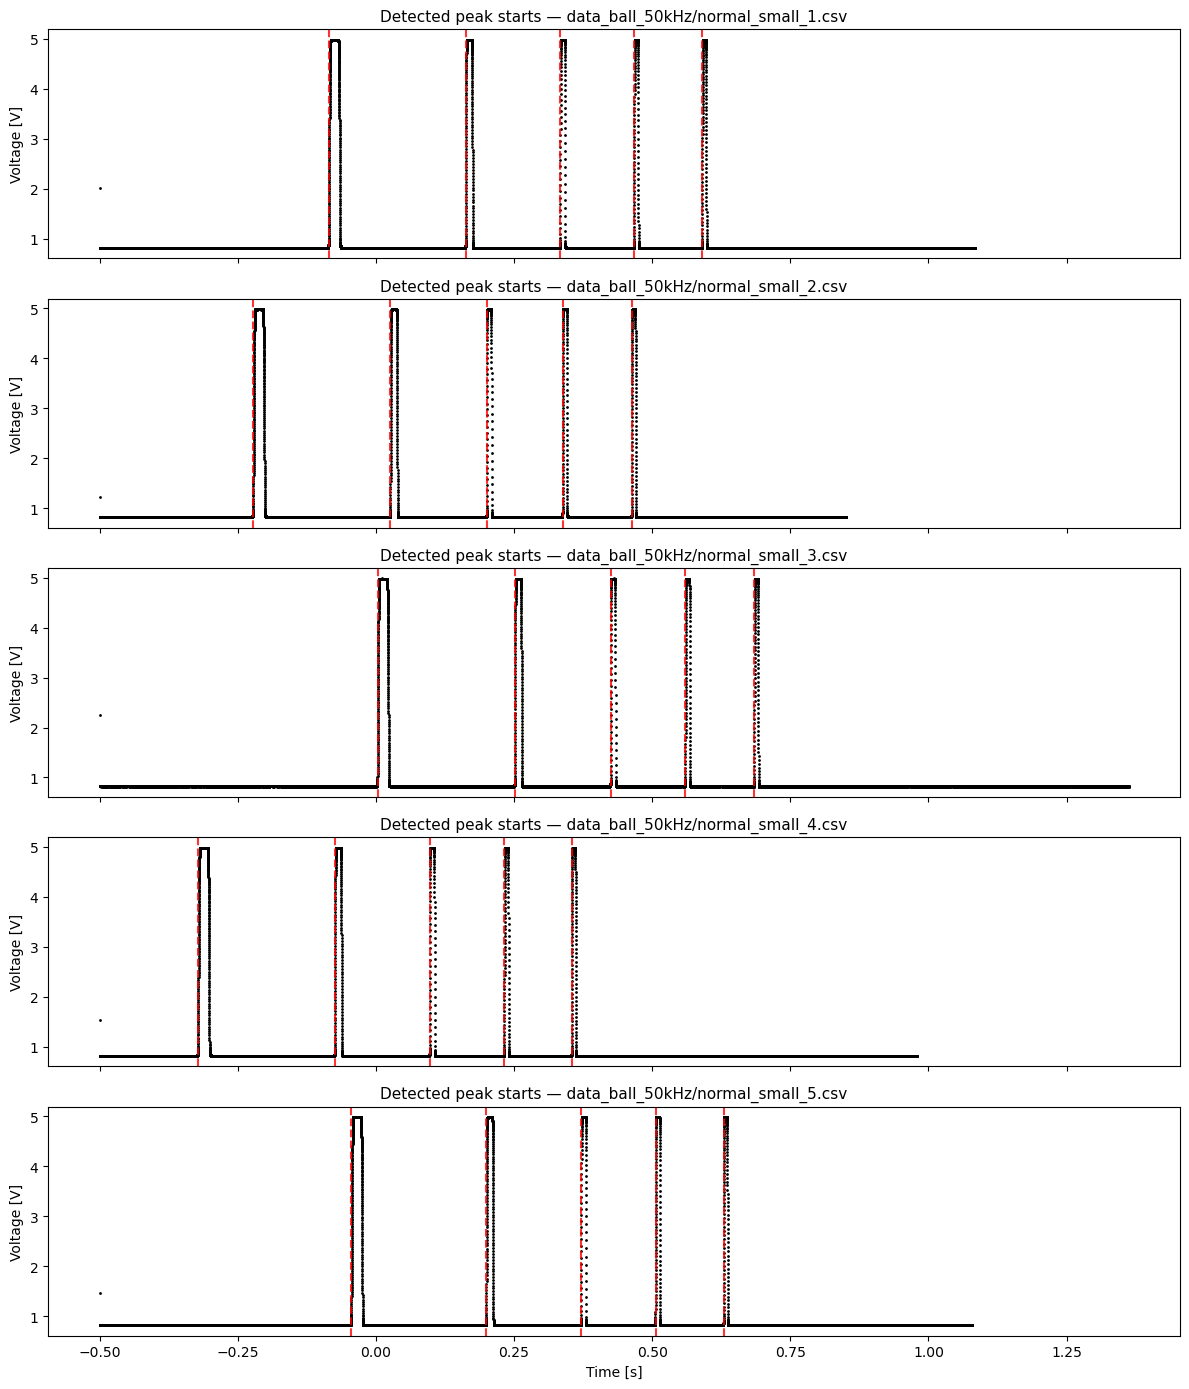

Original start times small ball, normal:
[[-0.08518082  0.16259971  0.33374595  0.46723186  0.59056656]
 [-0.22174039  0.02629672  0.2008187   0.33784209  0.46288194]
 [ 0.00299123  0.25142444  0.42486033  0.56010612  0.68484079]
 [-0.32169801 -0.07429306  0.09762302  0.23237707  0.35436261]
 [-0.04426507  0.19997157  0.37156731  0.50599903  0.62928828]]

Shifted start times (T1 = 0) small ball, normal:
[[0.         0.24778053 0.41892677 0.55241268 0.67574737]
 [0.         0.24803711 0.4225591  0.55958249 0.68462233]
 [0.         0.24843321 0.4218691  0.55711489 0.68184956]
 [0.         0.24740495 0.41932102 0.55407508 0.67606062]
 [0.         0.24423664 0.41583238 0.5502641  0.67355335]]


In [21]:
# ---------- Configure your 5 files ----------
filenames = [
    "data_ball_50kHz/normal_small_1.csv",
    "data_ball_50kHz/normal_small_2.csv",
    "data_ball_50kHz/normal_small_3.csv",
    "data_ball_50kHz/normal_small_4.csv",
    "data_ball_50kHz/normal_small_5.csv",
]

all_time_arrays = []   # list: each element is np.array of start times for one dataset

# Optional: params you may want to tune once for all datasets
SMOOTH_W = 5
MIN_PROM = 0.7          # raise if you see extra detections; lower if missing peaks
MIN_SEP_S = 0.08        # expected min spacing between spikes
REL_H = 0.08            # 5–10%: early start; 0.15–0.20: later start
MIN_HEIGHT = None       # or set e.g. baseline+0.3 if needed

# ---------- Load, compute, and plot ----------
n = len(filenames)
fig, axes = plt.subplots(nrows=n, ncols=1, figsize=(12, 2.8*n), sharex=True)

if n == 1:
    axes = [axes]  # make iterable if single

for ax, fname in zip(axes, filenames):
    # Load data
    time, voltage = read_csv(fname)

    # (Optional) shift time to start at zero across files
    # time = time - time.min()

    # Find starts
    starts, peaks = find_peak_starts(
        time, voltage,
        smooth_w=SMOOTH_W,
        min_height=MIN_HEIGHT,
        min_prom=MIN_PROM,
        min_separation_s=MIN_SEP_S,
        rel_height=REL_H
    )
    all_time_arrays = np.append(all_time_arrays, starts)
    # Print to console
    print(f"\n{fname} — Five peak-start times (s):")
    if len(starts) == 0:
        print("  No peaks detected. Try adjusting MIN_PROM / MIN_HEIGHT / REL_H.")
    else:
        for t in starts:
            print(f"  {t:.6f}")

    # Plot
    ax.plot(time, voltage, ".k", markersize=2)
    for t in starts:
        ax.axvline(t, color="r", ls="--", alpha=0.8)

    # Styling
    ax.set_title(f"Detected peak starts — {fname}", fontsize=11)
    ax.set_ylabel("Voltage [V]")

axes[-1].set_xlabel("Time [s]")
fig.tight_layout()
plt.show()

start_times_matrix = all_time_arrays.reshape(5, 5)   # rows = datasets (1..5), cols = T1..T5 
print("Original start times small ball, normal:")
print(start_times_matrix)

shifted_start_times_matrix_small_normal = start_times_matrix - start_times_matrix[:, [0]]
print("\nShifted start times (T1 = 0) small ball, normal:")
print(shifted_start_times_matrix_small_normal)


data_ball_50kHz/reverse_big_1.csv — Five peak-start times (s):
  -0.136601
  0.093729
  0.253948
  0.380128
  0.494361

data_ball_50kHz/reverse_big_2.csv — Five peak-start times (s):
  0.007018
  0.238000
  0.398247
  0.524472
  0.638894

data_ball_50kHz/reverse_big_3.csv — Five peak-start times (s):
  -0.137702
  0.091407
  0.251063
  0.376898
  0.490853

data_ball_50kHz/reverse_big_4.csv — Five peak-start times (s):
  -0.290751
  -0.060127
  0.100042
  0.226110
  0.340334

data_ball_50kHz/reverse_big_5.csv — Five peak-start times (s):
  0.145365
  0.375735
  0.535778
  0.661839
  0.776153


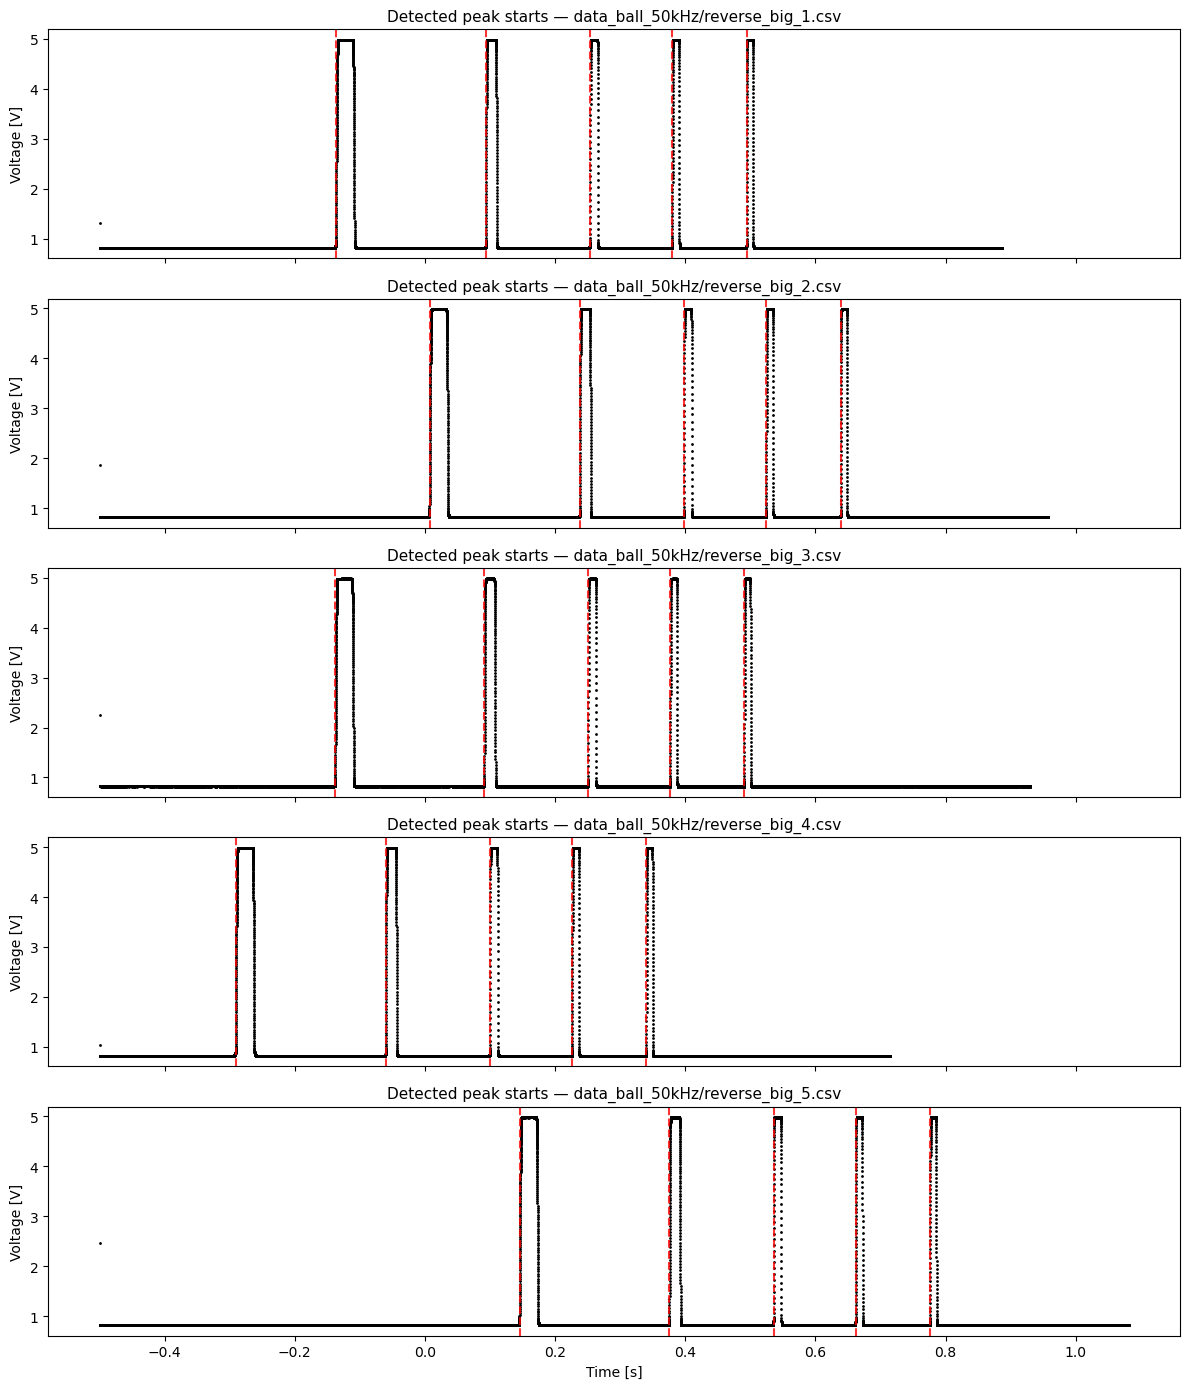

Original start times big ball, reverse:
[[-0.13660133  0.09372888  0.25394774  0.38012764  0.49436084]
 [ 0.00701757  0.23800011  0.39824689  0.52447154  0.63889402]
 [-0.13770207  0.09140694  0.25106278  0.37689756  0.49085346]
 [-0.29075057 -0.06012713  0.10004249  0.22610951  0.34033413]
 [ 0.14536527  0.37573534  0.53577754  0.66183927  0.77615282]]

Shifted start times (T1 = 0) big ball, reverse:
[[0.         0.23033021 0.39054908 0.51672897 0.63096217]
 [0.         0.23098254 0.39122932 0.51745397 0.63187645]
 [0.         0.22910901 0.38876486 0.51459963 0.62855554]
 [0.         0.23062344 0.39079306 0.51686008 0.6310847 ]
 [0.         0.23037008 0.39041227 0.516474   0.63078755]]


In [22]:
# ---------- Configure your 5 files ----------
filenames = [
    "data_ball_50kHz/reverse_big_1.csv",
    "data_ball_50kHz/reverse_big_2.csv",
    "data_ball_50kHz/reverse_big_3.csv",
    "data_ball_50kHz/reverse_big_4.csv",
    "data_ball_50kHz/reverse_big_5.csv",
]

all_time_arrays = []   # list: each element is np.array of start times for one dataset

# Optional: params you may want to tune once for all datasets
SMOOTH_W = 5
MIN_PROM = 0.7          # raise if you see extra detections; lower if missing peaks
MIN_SEP_S = 0.08        # expected min spacing between spikes
REL_H = 0.08            # 5–10%: early start; 0.15–0.20: later start
MIN_HEIGHT = None       # or set e.g. baseline+0.3 if needed

# ---------- Load, compute, and plot ----------
n = len(filenames)
fig, axes = plt.subplots(nrows=n, ncols=1, figsize=(12, 2.8*n), sharex=True)

if n == 1:
    axes = [axes]  # make iterable if single

for ax, fname in zip(axes, filenames):
    # Load data
    time, voltage = read_csv(fname)

    # (Optional) shift time to start at zero across files
    # time = time - time.min()

    # Find starts
    starts, peaks = find_peak_starts(
        time, voltage,
        smooth_w=SMOOTH_W,
        min_height=MIN_HEIGHT,
        min_prom=MIN_PROM,
        min_separation_s=MIN_SEP_S,
        rel_height=REL_H
    )
    all_time_arrays = np.append(all_time_arrays, starts)
    # Print to console
    print(f"\n{fname} — Five peak-start times (s):")
    if len(starts) == 0:
        print("  No peaks detected. Try adjusting MIN_PROM / MIN_HEIGHT / REL_H.")
    else:
        for t in starts:
            print(f"  {t:.6f}")

    # Plot
    ax.plot(time, voltage, ".k", markersize=2)
    for t in starts:
        ax.axvline(t, color="r", ls="--", alpha=0.8)

    # Styling
    ax.set_title(f"Detected peak starts — {fname}", fontsize=11)
    ax.set_ylabel("Voltage [V]")

axes[-1].set_xlabel("Time [s]")
fig.tight_layout()
plt.show()

start_times_matrix = all_time_arrays.reshape(5, 5)   # rows = datasets (1..5), cols = T1..T5 
print("Original start times big ball, reverse:")
print(start_times_matrix)

shifted_start_times_matrix_big_reverse = start_times_matrix - start_times_matrix[:, [0]]
print("\nShifted start times (T1 = 0) big ball, reverse:")
print(shifted_start_times_matrix_big_reverse)


data_ball_50kHz/reverse_medium_1.csv — Five peak-start times (s):
  -0.316809
  -0.083841
  0.079388
  0.208191
  0.325249

data_ball_50kHz/reverse_medium_2.csv — Five peak-start times (s):
  -0.274386
  -0.040887
  0.122255
  0.250965
  0.367713

data_ball_50kHz/reverse_medium_3.csv — Five peak-start times (s):
  -0.417210
  -0.183741
  -0.020689
  0.107810
  0.224720

data_ball_50kHz/reverse_medium_4.csv — Five peak-start times (s):
  -0.314125
  -0.080916
  0.082109
  0.210551
  0.327261

data_ball_50kHz/reverse_medium_5.csv — Five peak-start times (s):
  -0.116392
  0.117312
  0.280522
  0.409037
  0.525934


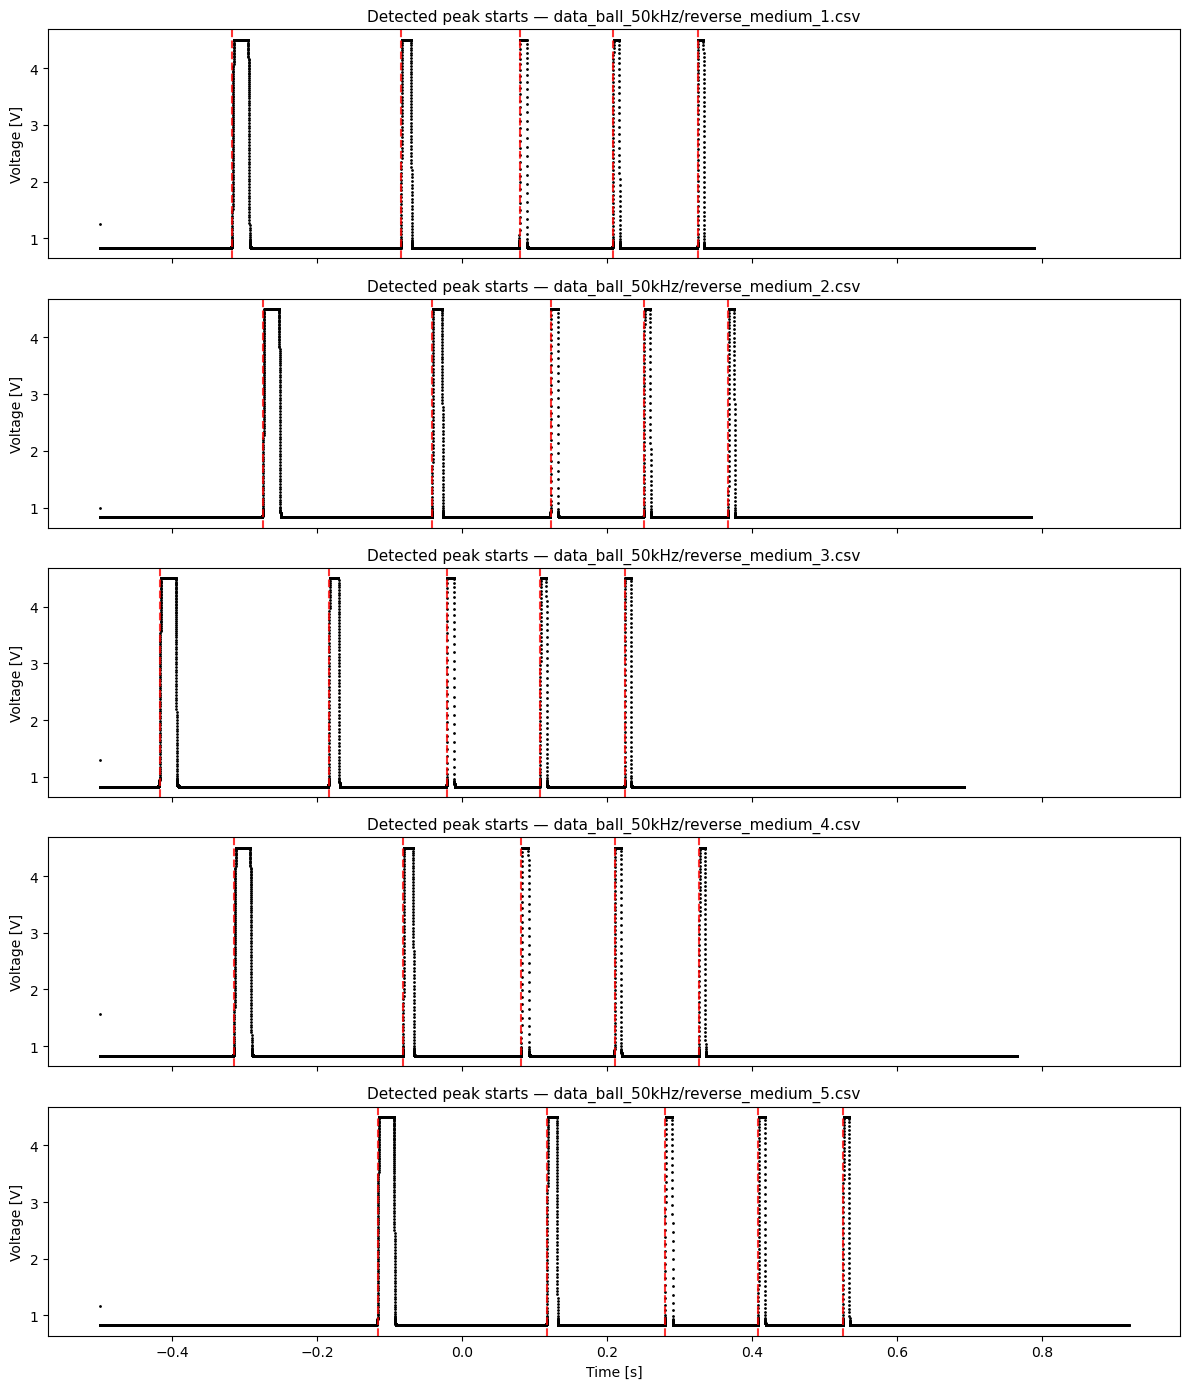

Original start times medium ball, reverse:
[[-0.31680855 -0.08384097  0.07938814  0.20819054  0.32524866]
 [-0.27438607 -0.04088746  0.12225473  0.2509646   0.36771259]
 [-0.41720997 -0.18374089 -0.02068932  0.10781048  0.22472009]
 [-0.3141247  -0.08091584  0.08210942  0.2105514   0.3272609 ]
 [-0.11639194  0.11731182  0.28052185  0.40903718  0.52593404]]

Shifted start times (T1 = 0) medium ball, reverse:
[[0.         0.23296757 0.39619669 0.52499909 0.64205721]
 [0.         0.23349861 0.39664079 0.52535067 0.64209866]
 [0.         0.23346907 0.39652064 0.52502044 0.64193006]
 [0.         0.23320886 0.39623412 0.5246761  0.6413856 ]
 [0.         0.23370376 0.39691379 0.52542912 0.64232598]]


In [23]:
# ---------- Configure your 5 files ----------
filenames = [
    "data_ball_50kHz/reverse_medium_1.csv",
    "data_ball_50kHz/reverse_medium_2.csv",
    "data_ball_50kHz/reverse_medium_3.csv",
    "data_ball_50kHz/reverse_medium_4.csv",
    "data_ball_50kHz/reverse_medium_5.csv",
]

all_time_arrays = []   # list: each element is np.array of start times for one dataset

# Optional: params you may want to tune once for all datasets
SMOOTH_W = 5
MIN_PROM = 0.7          # raise if you see extra detections; lower if missing peaks
MIN_SEP_S = 0.08        # expected min spacing between spikes
REL_H = 0.08            # 5–10%: early start; 0.15–0.20: later start
MIN_HEIGHT = None       # or set e.g. baseline+0.3 if needed

# ---------- Load, compute, and plot ----------
n = len(filenames)
fig, axes = plt.subplots(nrows=n, ncols=1, figsize=(12, 2.8*n), sharex=True)

if n == 1:
    axes = [axes]  # make iterable if single

for ax, fname in zip(axes, filenames):
    # Load data
    time, voltage = read_csv(fname)

    # (Optional) shift time to start at zero across files
    # time = time - time.min()

    # Find starts
    starts, peaks = find_peak_starts(
        time, voltage,
        smooth_w=SMOOTH_W,
        min_height=MIN_HEIGHT,
        min_prom=MIN_PROM,
        min_separation_s=MIN_SEP_S,
        rel_height=REL_H
    )
    all_time_arrays = np.append(all_time_arrays, starts)
    # Print to console
    print(f"\n{fname} — Five peak-start times (s):")
    if len(starts) == 0:
        print("  No peaks detected. Try adjusting MIN_PROM / MIN_HEIGHT / REL_H.")
    else:
        for t in starts:
            print(f"  {t:.6f}")

    # Plot
    ax.plot(time, voltage, ".k", markersize=2)
    for t in starts:
        ax.axvline(t, color="r", ls="--", alpha=0.8)

    # Styling
    ax.set_title(f"Detected peak starts — {fname}", fontsize=11)
    ax.set_ylabel("Voltage [V]")

axes[-1].set_xlabel("Time [s]")
fig.tight_layout()
plt.show()

start_times_matrix = all_time_arrays.reshape(5, 5)   # rows = datasets (1..5), cols = T1..T5 
print("Original start times medium ball, reverse:")
print(start_times_matrix)

shifted_start_times_matrix_medium_reverse = start_times_matrix - start_times_matrix[:, [0]]
print("\nShifted start times (T1 = 0) medium ball, reverse:")
print(shifted_start_times_matrix_medium_reverse)


data_ball_50kHz/reverse_small_1.csv — Five peak-start times (s):
  0.077626
  0.321252
  0.491898
  0.625765
  0.746889

data_ball_50kHz/reverse_small_2.csv — Five peak-start times (s):
  -0.190136
  0.057256
  0.230170
  0.366224
  0.488453

data_ball_50kHz/reverse_small_3.csv — Five peak-start times (s):
  -0.171007
  0.077569
  0.251329
  0.388534
  0.512715

data_ball_50kHz/reverse_small_4.csv — Five peak-start times (s):
  -0.169259
  0.072966
  0.243083
  0.375619
  0.492091

data_ball_50kHz/reverse_small_5.csv — Five peak-start times (s):
  -0.297377
  -0.048956
  0.123524
  0.259807
  0.383610


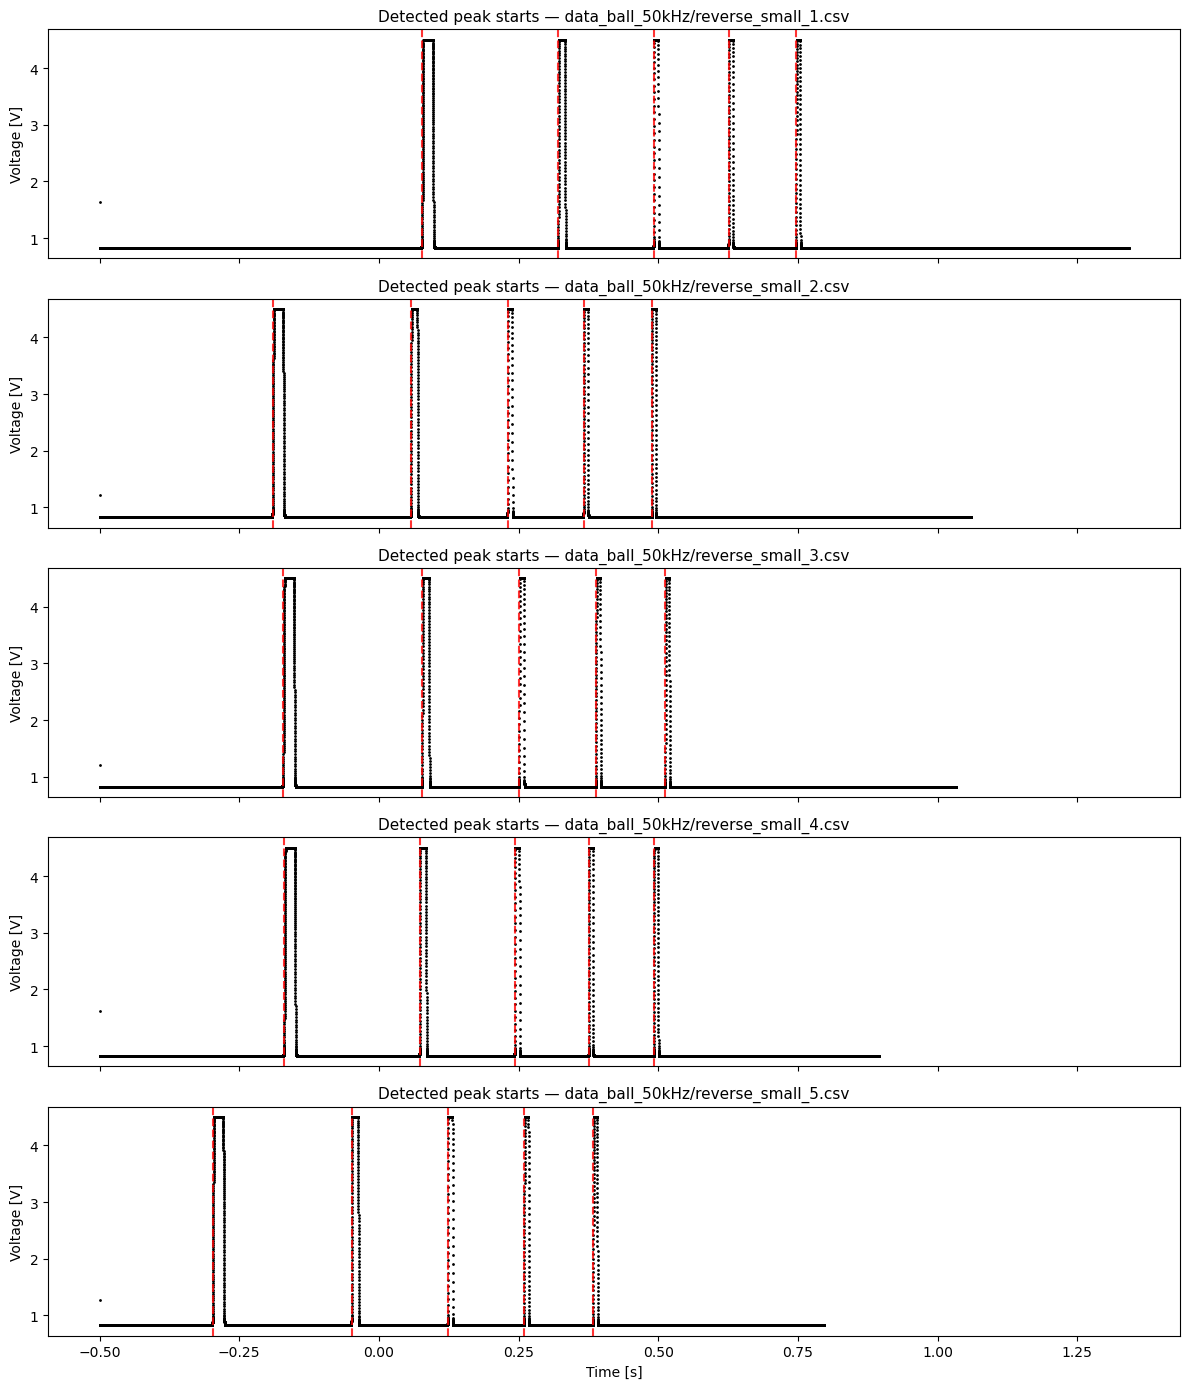

Original start times small ball, reverse:
[[ 0.07762557  0.32125154  0.49189822  0.62576542  0.74688925]
 [-0.19013553  0.0572558   0.23016974  0.36622412  0.48845259]
 [-0.17100665  0.07756889  0.25132884  0.38853441  0.51271487]
 [-0.16925888  0.07296551  0.24308323  0.3756187   0.49209101]
 [-0.2973772  -0.04895616  0.12352356  0.25980682  0.38360978]]

Shifted start times (T1 = 0) small ball, reverse:
[[0.         0.24362597 0.41427265 0.54813985 0.66926369]
 [0.         0.24739133 0.42030527 0.55635965 0.67858812]
 [0.         0.24857554 0.42233549 0.55954106 0.68372152]
 [0.         0.24222439 0.41234211 0.54487759 0.6613499 ]
 [0.         0.24842104 0.42090077 0.55718402 0.68098698]]


In [24]:
# ---------- Configure your 5 files ----------
filenames = [
    "data_ball_50kHz/reverse_small_1.csv",
    "data_ball_50kHz/reverse_small_2.csv",
    "data_ball_50kHz/reverse_small_3.csv",
    "data_ball_50kHz/reverse_small_4.csv",
    "data_ball_50kHz/reverse_small_5.csv",
]

all_time_arrays = []   # list: each element is np.array of start times for one dataset

# Optional: params you may want to tune once for all datasets
SMOOTH_W = 5
MIN_PROM = 0.7          # raise if you see extra detections; lower if missing peaks
MIN_SEP_S = 0.08        # expected min spacing between spikes
REL_H = 0.08            # 5–10%: early start; 0.15–0.20: later start
MIN_HEIGHT = None       # or set e.g. baseline+0.3 if needed

# ---------- Load, compute, and plot ----------
n = len(filenames)
fig, axes = plt.subplots(nrows=n, ncols=1, figsize=(12, 2.8*n), sharex=True)

if n == 1:
    axes = [axes]  # make iterable if single

for ax, fname in zip(axes, filenames):
    # Load data
    time, voltage = read_csv(fname)

    # (Optional) shift time to start at zero across files
    # time = time - time.min()

    # Find starts
    starts, peaks = find_peak_starts(
        time, voltage,
        smooth_w=SMOOTH_W,
        min_height=MIN_HEIGHT,
        min_prom=MIN_PROM,
        min_separation_s=MIN_SEP_S,
        rel_height=REL_H
    )
    all_time_arrays = np.append(all_time_arrays, starts)
    # Print to console
    print(f"\n{fname} — Five peak-start times (s):")
    if len(starts) == 0:
        print("  No peaks detected. Try adjusting MIN_PROM / MIN_HEIGHT / REL_H.")
    else:
        for t in starts:
            print(f"  {t:.6f}")

    # Plot
    ax.plot(time, voltage, ".k", markersize=2)
    for t in starts:
        ax.axvline(t, color="r", ls="--", alpha=0.8)

    # Styling
    ax.set_title(f"Detected peak starts — {fname}", fontsize=11)
    ax.set_ylabel("Voltage [V]")

axes[-1].set_xlabel("Time [s]")
fig.tight_layout()
plt.show()

start_times_matrix = all_time_arrays.reshape(5, 5)   # rows = datasets (1..5), cols = T1..T5 
print("Original start times small ball, reverse:")
print(start_times_matrix)

shifted_start_times_matrix_small_reverse = start_times_matrix - start_times_matrix[:, [0]]
print("\nShifted start times (T1 = 0) small ball, reverse:")
print(shifted_start_times_matrix_small_reverse)

## All acceleration data

In [25]:
print("\nShifted start times (T1 = 0) big ball, normal:")
print(shifted_start_times_matrix_big_normal)

print("\nShifted start times (T1 = 0) medium ball, normal:")
print(shifted_start_times_matrix_medium_normal)

print("\nShifted start times (T1 = 0) small ball, normal:")
print(shifted_start_times_matrix_small_normal)


Shifted start times (T1 = 0) big ball, normal:
[[0.         0.23002919 0.38995319 0.51595726 0.6302457 ]
 [0.         0.23078166 0.39088404 0.5169469  0.63125309]
 [0.         0.23076448 0.39090654 0.51702569 0.63109638]
 [0.         0.22996401 0.38970434 0.51562299 0.62964813]
 [0.         0.22913371 0.3886386  0.51442143 0.62834884]]

Shifted start times (T1 = 0) medium ball, normal:
[[0.         0.23441974 0.39766703 0.52654026 0.64326053]
 [0.         0.23354781 0.39650575 0.52498905 0.64167403]
 [0.         0.23322094 0.3961597  0.52455024 0.64131232]
 [0.         0.23291698 0.39547221 0.5237973  0.63984305]
 [0.         0.23335871 0.3963717  0.52482906 0.64142964]]

Shifted start times (T1 = 0) small ball, normal:
[[0.         0.24778053 0.41892677 0.55241268 0.67574737]
 [0.         0.24803711 0.4225591  0.55958249 0.68462233]
 [0.         0.24843321 0.4218691  0.55711489 0.68184956]
 [0.         0.24740495 0.41932102 0.55407508 0.67606062]
 [0.         0.24423664 0.41583238 0.

In [26]:
print("\nShifted start times (T1 = 0) big ball, reverse:")
print(shifted_start_times_matrix_big_reverse)

print("\nShifted start times (T1 = 0) medium ball, reverse:")
print(shifted_start_times_matrix_medium_reverse)

print("\nShifted start times (T1 = 0) small ball, reverse:")
print(shifted_start_times_matrix_small_reverse)


Shifted start times (T1 = 0) big ball, reverse:
[[0.         0.23033021 0.39054908 0.51672897 0.63096217]
 [0.         0.23098254 0.39122932 0.51745397 0.63187645]
 [0.         0.22910901 0.38876486 0.51459963 0.62855554]
 [0.         0.23062344 0.39079306 0.51686008 0.6310847 ]
 [0.         0.23037008 0.39041227 0.516474   0.63078755]]

Shifted start times (T1 = 0) medium ball, reverse:
[[0.         0.23296757 0.39619669 0.52499909 0.64205721]
 [0.         0.23349861 0.39664079 0.52535067 0.64209866]
 [0.         0.23346907 0.39652064 0.52502044 0.64193006]
 [0.         0.23320886 0.39623412 0.5246761  0.6413856 ]
 [0.         0.23370376 0.39691379 0.52542912 0.64232598]]

Shifted start times (T1 = 0) small ball, reverse:
[[0.         0.24362597 0.41427265 0.54813985 0.66926369]
 [0.         0.24739133 0.42030527 0.55635965 0.67858812]
 [0.         0.24857554 0.42233549 0.55954106 0.68372152]
 [0.         0.24222439 0.41234211 0.54487759 0.6613499 ]
 [0.         0.24842104 0.42090077

## Mean of time from voltage from 5 experiments

In [27]:
matrices_experiments = [
    shifted_start_times_matrix_big_normal,
    shifted_start_times_matrix_medium_normal,
    shifted_start_times_matrix_small_normal,
    shifted_start_times_matrix_big_reverse,
    shifted_start_times_matrix_medium_reverse,
    shifted_start_times_matrix_small_reverse]

n_experiments = 6

rows = []  # each row = gate-mean per time for one experiment

for i in range(n_experiments):
    # mean across gates for each time in experiment i
    row = np.mean(matrices_experiments[i], axis=0)  # shape: (n_times,)
    rows.append(row)

t_mean_gate = np.vstack(rows)          # shape: (n_experiments, n_times)

print("means from times of gates from:  \nshifted_start_times_matrix_big_normal,  \nshifted_start_times_matrix_medium_normal,  \nshifted_start_times_matrix_small_normal,  \nshifted_start_times_matrix_big_reverse,  \nshifted_start_times_matrix_medium_reverse,  \nshifted_start_times_matrix_small_reverse \n =")
print(t_mean_gate)

means from times of gates from:  
shifted_start_times_matrix_big_normal,  
shifted_start_times_matrix_medium_normal,  
shifted_start_times_matrix_small_normal,  
shifted_start_times_matrix_big_reverse,  
shifted_start_times_matrix_medium_reverse,  
shifted_start_times_matrix_small_reverse 
 =
[[0.         0.23013461 0.39001734 0.51599486 0.63011843]
 [0.         0.23349284 0.39643528 0.52494118 0.64150391]
 [0.         0.24717849 0.41970167 0.55468985 0.67836665]
 [0.         0.23028305 0.39034972 0.51642333 0.63065328]
 [0.         0.23336957 0.39650121 0.52509508 0.6419595 ]
 [0.         0.24604766 0.41803126 0.55322044 0.67478204]]


## Plots for calculating the acceleration

In [28]:
def quadratic_fit(t,p0, p1, p2):
    return p0 + p1 * t + 1/2 * p2 * t**2

In [29]:
# ---- Global style tweaks (safe to run once) ----
mpl.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "font.size": 12,
    "axes.titlesize": 14,
    "axes.labelsize": 13,
    "legend.fontsize": 11,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "axes.linewidth": 1.0,
    "grid.alpha": 0.25,
})
plt.style.use("seaborn-v0_8-whitegrid")  # stable seaborn style

def plot_iminuit_fit_using_model(
    mfit,
    t, y,
    model,            # your quadratic_fit(t, p0, p1, p2) ; p2 is acceleration
    yerr=None,        # optional position uncertainties
    xerr=None,        # optional time uncertainties -> horizontal bars in residuals
    title_top="Ball position measurements [m]",
    person=None,
    ball_size=None,
    orientation=None,
    curve_color="#1f77b4",  # seaborn default blue
    data_color="black",
    resid_color="#d62728",  # seaborn default red
):
    """Prettier two-panel plot using an iminuit.Minuit fit of your quadratic model."""
    # ---- Prepare data ----
    t = np.asarray(t, dtype=float)
    y = np.asarray(y, dtype=float)
    if yerr is not None:
        yerr = np.asarray(yerr, dtype=float)
    if xerr is not None:
        xerr = np.asarray(xerr, dtype=float)

    # ---- Extract parameters ----
    par_names = list(mfit.parameters)
    pvals = {name: float(mfit.values[name]) for name in par_names}
    perrs = {name: float(mfit.errors[name]) for name in par_names}

    # Expect names p0,p1,p2; fall back gracefully otherwise
    try:
        p0 = pvals["p0"]; p1 = pvals["p1"]; p2 = pvals["p2"]
        s0 = perrs["p0"]; s1 = perrs["p1"]; s2 = perrs["p2"]
    except KeyError:
        p0, p1, p2 = [pvals[n] for n in par_names[:3]]
        s0, s1, s2 = [perrs[n] for n in par_names[:3]]

    # Fitted curve + residuals
    y_fit = model(t, p0, p1, p2)
    resid = y - y_fit

    # Residual guide sigma
    if yerr is not None and np.any(np.isfinite(yerr)):
        sigma_guide = float(np.nanmean(yerr))
        unc_source = "as provided (σᵧ)"
    else:
        sigma_guide = float(np.sqrt(np.nanmean(resid**2))) if resid.size else 0.0
        unc_source = "obtained from RMS of residuals"

    # Goodness-of-fit
    chi2_val = float(mfit.fval)          # With iminuit.cost.LeastSquares => χ²
    ndof     = int(len(t) - mfit.nfit)   # Npoints − Nparams
    pval     = float(chi2.sf(chi2_val, ndof)) if (_SCIPY and ndof > 0) else np.nan

    # ---- Figure & axes ----
    fig = plt.figure(figsize=(9.5, 5.8), constrained_layout=True)
    gs  = fig.add_gridspec(nrows=2, ncols=1, height_ratios=[3.2, 1.6])
    ax_top = fig.add_subplot(gs[0, 0])
    ax_bot = fig.add_subplot(gs[1, 0], sharex=ax_top)

    # ---- Top: data + fit ----
    # Data
    if yerr is not None:
        ax_top.errorbar(
            t, y, yerr=yerr, fmt="o", ms=5,
            color=data_color, ecolor="gray", elinewidth=1.2, capsize=3,
            label="Measurements"
        )
    else:
        ax_top.plot(t, y, "o", color=data_color, ms=5, label="Measurements")

    # Smooth curve
    t_curve = np.linspace(t.min(), t.max(), 600)
    y_curve = model(t_curve, p0, p1, p2)
    ax_top.plot(t_curve, y_curve, color=curve_color, lw=2.4, label="Fitted model")

    # Axes formatting
    ax_top.set_title(title_top, pad=8)
    ax_top.set_ylabel("Position [m]")
    ax_top.grid(True, which="major", linestyle="-", alpha=0.25)
    ax_top.grid(True, which="minor", linestyle=":", alpha=0.18)
    ax_top.minorticks_on()
    ax_top.legend(frameon=False, loc="upper left")

    # Annotation box (semi-transparent)
    a_fit, sa_fit = p2, s2  # because your model uses ½ * a * t^2
    meta_lines = []
    if person:      meta_lines.append(f"Person taking measurements: {person}")
    if ball_size:   meta_lines.append(f"Ball size: {ball_size}")
    if orientation: meta_lines.append(f"Orientation: {orientation}")
    meta_lines += [
        "",
        rf"Acceleration fitted = {a_fit:.4g} ± {sa_fit:.2g} m/s$^2$",
        #"Uncertainty on measurements",
        #unc_source,
        "",
        rf"p ($\chi^2$ = {chi2_val:.3g}, $N_{{dof}}$ = {ndof}) = {pval:.3g}"
    ]
    # Position the box near top-left but inside axes limits
    bbox_props = dict(boxstyle="round", facecolor="white", alpha=0.75, edgecolor="none")
    ax_top.text(
        0.02, 0.80, "\n".join(meta_lines),
        transform=ax_top.transAxes, va="top", ha="left",
        color="#0b3d91", fontsize=11, bbox=bbox_props
    )

    # Right axis label (subtle)
    ax_top_right = ax_top.twinx()
    ax_top_right.set_ylabel("Residuals", color="dimgray")
    ax_top_right.tick_params(axis='y', colors='dimgray')
    ax_top_right.grid(False)

    # Tidy x-limits + y-limits
    t_span = t.max() - t.min()
    ax_top.set_xlim(t.min() - 0.03*t_span, t.max() + 0.03*t_span)
    # Ensure a small top/bottom margin
    y_min = min(np.min(y), np.min(y_curve))
    y_max = max(np.max(y), np.max(y_curve))
    y_pad = 0.05 * (y_max - y_min if y_max > y_min else 1.0)
    ax_top.set_ylim(y_min - y_pad, y_max + y_pad)

    # ---- Bottom: residuals ----
    ax_bot.axhline(0.0, color="k", lw=1.0)
    ax_bot.axhline(+sigma_guide, color="gray", lw=1.0, ls="--", alpha=0.85)
    ax_bot.axhline(-sigma_guide, color="gray", lw=1.0, ls="--", alpha=0.85)

    if yerr is not None:
        ax_bot.errorbar(
            t, resid, yerr=yerr, fmt="o", ms=5,
            color=resid_color, ecolor=resid_color, elinewidth=1.0, capsize=3
        )
    else:
        ax_bot.plot(t, resid, "o", color=resid_color, ms=5)

    # Horizontal time-error bars (if given)
    if xerr is not None:
        for ti, ri, sxi in zip(t, resid, xerr):
            ax_bot.hlines(ri, ti - sxi, ti + sxi, colors=resid_color, lw=1.5, alpha=0.9)

    # Residuals formatting
    ax_bot.set_xlabel("Time [s]")
    ax_bot.set_ylabel("Position residuals [m]")
    ax_bot.grid(True, which="major", linestyle="-", alpha=0.25)
    ax_bot.grid(True, which="minor", linestyle=":", alpha=0.18)
    ax_bot.minorticks_on()

    # Residual limits: symmetric around 0 with 10–20% headroom
    rmax = np.nanmax(np.abs(resid)) if resid.size else sigma_guide
    rpad = 0.15 * (rmax if rmax > 0 else sigma_guide if sigma_guide > 0 else 1e-6)
    ax_bot.set_ylim(-0.001, 0.001)

    # Clean scientific notation on x if very small numbers
    ax_bot.ticklabel_format(style="sci", axis="x", scilimits=(0, 0))

    # annotation for residuals
    ax_bot.text(
        0.015, 0.01,
        "Position residuals\nDashed lines show ±σ",
        transform=ax_bot.transAxes, ha="left", va="bottom",
        color=resid_color, fontsize=10
    )

    return fig, (ax_top, ax_bot), (a_fit, sa_fit), (p0, p1, p2), (s0, s1, s2), chi2_val, ndof


In [30]:
positions = np.array(gate_position_weighted_shifted)   # y-values
sx        = np.array(gate_position_weighted_err)       # y-uncertainties (position)
times_by_experiment = np.array(t_mean_gate)            # x-values per experiment (6 in total)

print(positions)
print(sx)
print(times_by_experiment)

[-0.82136466 -0.67166917 -0.51894511 -0.37035789 -0.21420226]
[0.00052027 0.00052027 0.00052027 0.00052027 0.00052027]
[[0.         0.23013461 0.39001734 0.51599486 0.63011843]
 [0.         0.23349284 0.39643528 0.52494118 0.64150391]
 [0.         0.24717849 0.41970167 0.55468985 0.67836665]
 [0.         0.23028305 0.39034972 0.51642333 0.63065328]
 [0.         0.23336957 0.39650121 0.52509508 0.6419595 ]
 [0.         0.24604766 0.41803126 0.55322044 0.67478204]]


In [31]:
Minuit.print_level = 1    # Print result of fits (generally - can also be moved down to each fit instance)

# Alternatively, use the Chi2 regression from External Functions:
cfit_normal_big = cost.LeastSquares(times_by_experiment[0], positions, sx, quadratic_fit)

# NOTE: Did you remember to ensure, that all bins had entries in them, i.e. that y>0?

mfit_normal_big = Minuit(cfit_normal_big, p0=0, p1=0, p2=0)
mfit_normal_big.migrad()           # This is where the minimisation is carried out! Put ";" at the end to void output

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 0.02182 (χ²/ndof = 0.0)    │              Nfcn = 72               │
│ EDM = 1.31e-14 (Goal: 0.0002)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ p0   │ -821.3e-3 │  0.5e-3   │            │            │         │         │       │
│ 1 │ p1   │   0.470   │   0.004   │            │            │         │         │       │
│ 2 │ p2   │   1.567   │   0.011   │            │            │         │         │       │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌────┬───────────────────────────────┐
│    │        p0        p1        p2 │
├────┼───────────────────────────────┤
│ p0 │  2.59e-07  -1.29e-6   2.88e-6 │
│ p1 │  -1.29e-6  1.31e-05 -0.039e-3 │
│ p2 │   2.88e-6 -0.039e-3  0.000124 │
└────┴───────────────────────────────┘

In [32]:
chi2_rev = mfit_normal_big.fval                     # ChiSquare value
Ndof_rev = len(times_by_experiment[0]) - mfit_normal_big.nfit     # Number of (non-empty) bins
Prob_rev = stats.chi2.sf(chi2_rev, Ndof_rev)     # ChiSquare probability given Ndof

print("Chi2 = ",chi2_rev)
print("number DOF = ", Ndof_rev)
print("Prob", Prob_rev)

Chi2 =  0.021818497735818225
number DOF =  2
Prob 0.9891500411883324


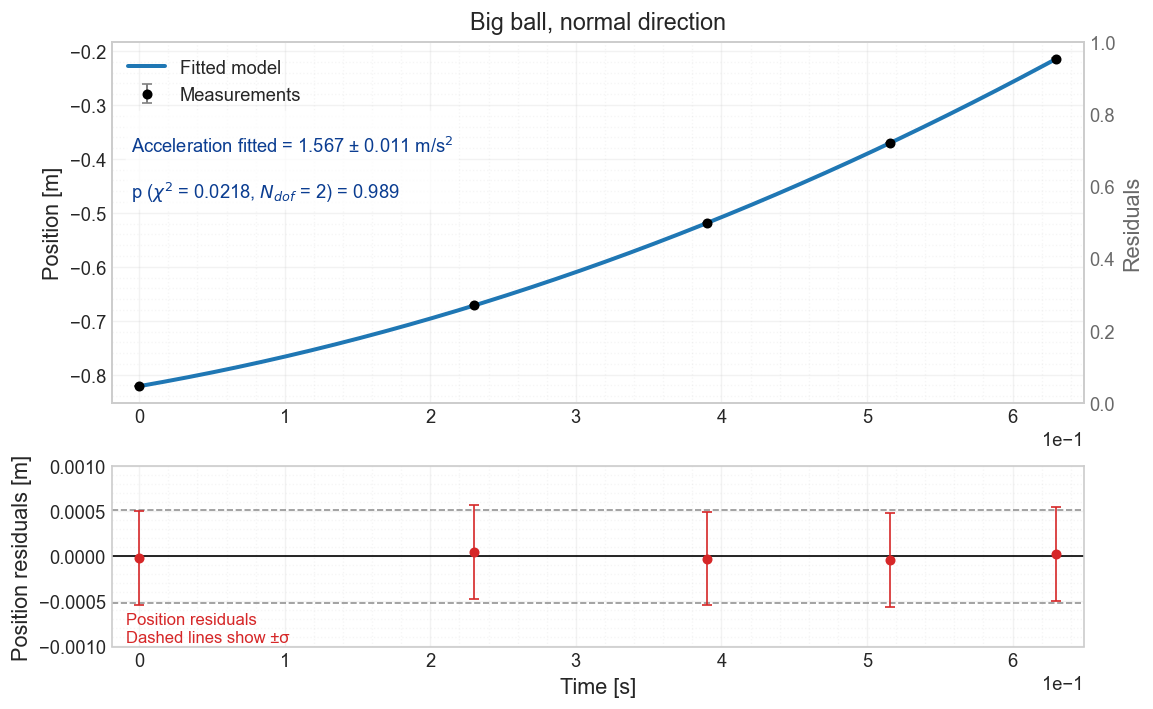

In [33]:
fig, axes, (a, sa), pars, perrs, chi2_val, ndof = plot_iminuit_fit_using_model(
    mfit=mfit_normal_big,
    t=times_by_experiment[0],
    y=positions,
    model=quadratic_fit,   # your function: p2 is acceleration
    yerr=gate_position_weighted_err,  # or None
    title_top="Big ball, normal direction",
)
plt.show()

In [34]:
# Alternatively, use the Chi2 regression from External Functions:
cfit_normal_medium = cost.LeastSquares(times_by_experiment[1], positions, sx, quadratic_fit)

# NOTE: Did you remember to ensure, that all bins had entries in them, i.e. that y>0?

mfit_normal_medium = Minuit(cfit_normal_medium, p0=0, p1=0, p2=0)
mfit_normal_medium.migrad()           # This is where the minimisation is carried out! Put ";" at the end to void output

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 0.0121 (χ²/ndof = 0.0)     │              Nfcn = 72               │
│ EDM = 1.72e-15 (Goal: 0.0002)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ p0   │ -821.4e-3 │  0.5e-3   │            │            │         │         │       │
│ 1 │ p1   │   0.466   │   0.004   │            │            │         │         │       │
│ 2 │ p2   │   1.498   │   0.011   │            │            │         │         │       │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌────┬───────────────────────────────┐
│    │        p0        p1        p2 │
├────┼───────────────────────────────┤
│ p0 │  2.59e-07  -1.27e-6   2.78e-6 │
│ p1 │  -1.27e-6  1.27e-05 -0.037e-3 │
│ p2 │   2.78e-6 -0.037e-3  0.000115 │
└────┴───────────────────────────────┘

In [35]:
chi2_rev = mfit_normal_medium.fval                     # ChiSquare value
Ndof_rev = len(times_by_experiment[1]) - mfit_normal_medium.nfit     # Number of (non-empty) bins
Prob_rev = stats.chi2.sf(chi2_rev, Ndof_rev)     # ChiSquare probability given Ndof

print("Chi2 = ",chi2_rev)
print("number DOF = ", Ndof_rev)
print("Prob", Prob_rev)

Chi2 =  0.012104657360435683
number DOF =  2
Prob 0.9939659497666948


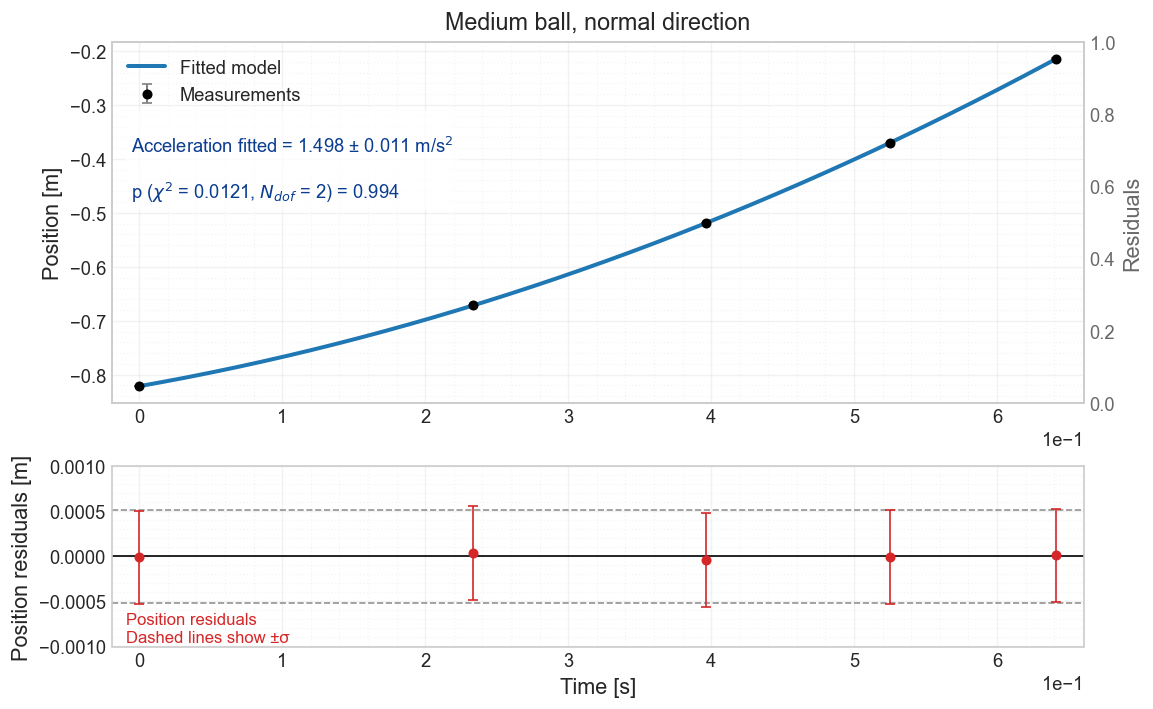

In [36]:
fig, axes, (a, sa), pars, perrs, chi2_val, ndof = plot_iminuit_fit_using_model(
    mfit=mfit_normal_medium,
    t=times_by_experiment[1],
    y=positions,
    model=quadratic_fit,   # your function: p2 is acceleration
    yerr=gate_position_weighted_err,  # or None
    title_top="Medium ball, normal direction",
)
plt.show()

In [37]:
# Alternatively, use the Chi2 regression from External Functions:
cfit_normal_small = cost.LeastSquares(times_by_experiment[2], positions, sx, quadratic_fit)

# NOTE: Did you remember to ensure, that all bins had entries in them, i.e. that y>0?

mfit_normal_small = Minuit(cfit_normal_small, p0=0, p1=0, p2=0)
mfit_normal_small.migrad()           # This is where the minimisation is carried out! Put ";" at the end to void output

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 1.562 (χ²/ndof = 0.8)      │              Nfcn = 72               │
│ EDM = 2.51e-14 (Goal: 0.0002)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ p0   │ -821.4e-3 │  0.5e-3   │            │            │         │         │       │
│ 1 │ p1   │  0.4393   │  0.0034   │            │            │         │         │       │
│ 2 │ p2   │   1.345   │   0.010   │            │            │         │         │       │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌────┬───────────────────────────────┐
│    │        p0        p1        p2 │
├────┼───────────────────────────────┤
│ p0 │  2.59e-07  -1.20e-6   2.49e-6 │
│ p1 │  -1.20e-6  1.13e-05 -0.031e-3 │
│ p2 │   2.49e-6 -0.031e-3  9.23e-05 │
└────┴───────────────────────────────┘

In [38]:
chi2_rev = mfit_normal_small.fval                     # ChiSquare value
Ndof_rev = len(times_by_experiment[2]) - mfit_normal_small.nfit     # Number of (non-empty) bins
Prob_rev = stats.chi2.sf(chi2_rev, Ndof_rev)     # ChiSquare probability given Ndof

print("Chi2 = ",chi2_rev)
print("number DOF = ", Ndof_rev)
print("Prob", Prob_rev)

Chi2 =  1.5616512612211533
number DOF =  2
Prob 0.45802769346710215


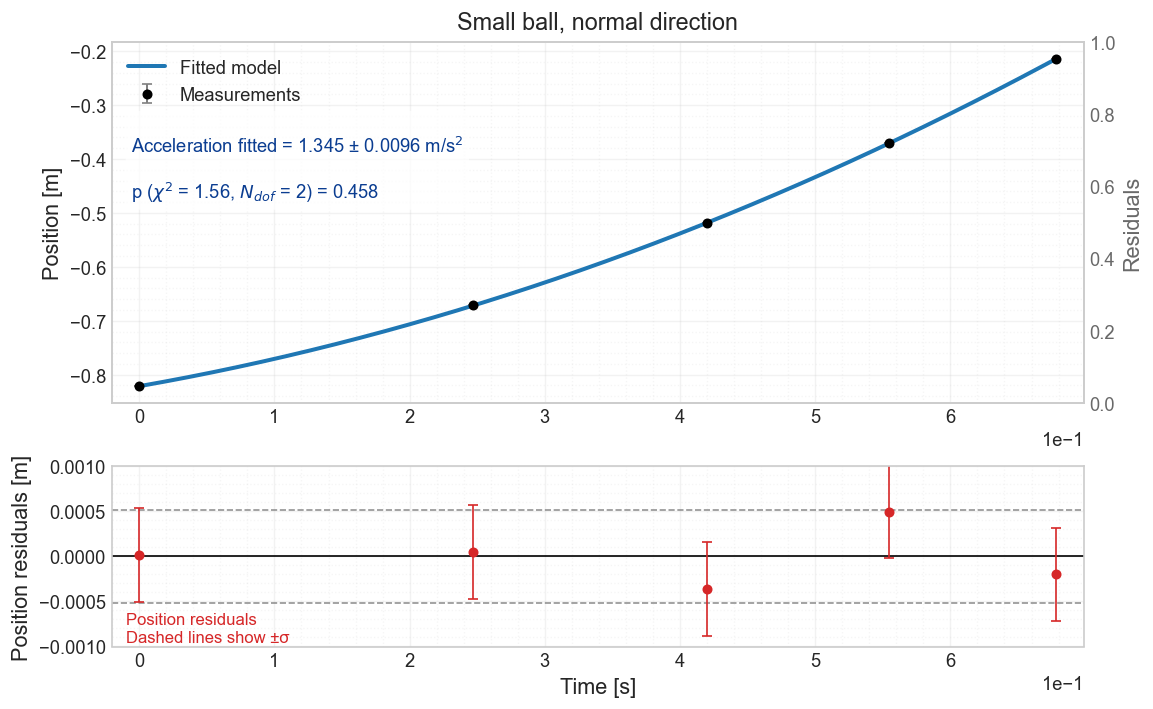

In [39]:
fig, axes, (a, sa), pars, perrs, chi2_val, ndof = plot_iminuit_fit_using_model(
    mfit=mfit_normal_small,
    t=times_by_experiment[2],
    y=positions,
    model=quadratic_fit,   # your function: p2 is acceleration
    yerr=gate_position_weighted_err,  # or None
    title_top="Small ball, normal direction",
)
plt.show()

In [40]:
# Alternatively, use the Chi2 regression from External Functions:
cfit_reverse_big = cost.LeastSquares(times_by_experiment[3], positions, sx, quadratic_fit)

# NOTE: Did you remember to ensure, that all bins had entries in them, i.e. that y>0?

mfit_reverse_big = Minuit(cfit_reverse_big, p0=0, p1=0, p2=0)
mfit_reverse_big.migrad()           # This is where the minimisation is carried out! Put ";" at the end to void output

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 0.03579 (χ²/ndof = 0.0)    │              Nfcn = 72               │
│ EDM = 1.33e-14 (Goal: 0.0002)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ p0   │ -821.3e-3 │  0.5e-3   │            │            │         │         │       │
│ 1 │ p1   │   0.470   │   0.004   │            │            │         │         │       │
│ 2 │ p2   │   1.564   │   0.011   │            │            │         │         │       │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌────┬───────────────────────────────┐
│    │        p0        p1        p2 │
├────┼───────────────────────────────┤
│ p0 │  2.59e-07  -1.29e-6   2.88e-6 │
│ p1 │  -1.29e-6  1.31e-05 -0.039e-3 │
│ p2 │   2.88e-6 -0.039e-3  0.000124 │
└────┴───────────────────────────────┘

In [41]:
chi2_rev = mfit_reverse_big.fval                     # ChiSquare value
Ndof_rev = len(times_by_experiment[3]) - mfit_reverse_big.nfit     # Number of (non-empty) bins
Prob_rev = stats.chi2.sf(chi2_rev, Ndof_rev)     # ChiSquare probability given Ndof

print("Chi2 = ",chi2_rev)
print("number DOF = ", Ndof_rev)
print("Prob", Prob_rev)

Chi2 =  0.03579435710821719
number DOF =  2
Prob 0.9822620247677498


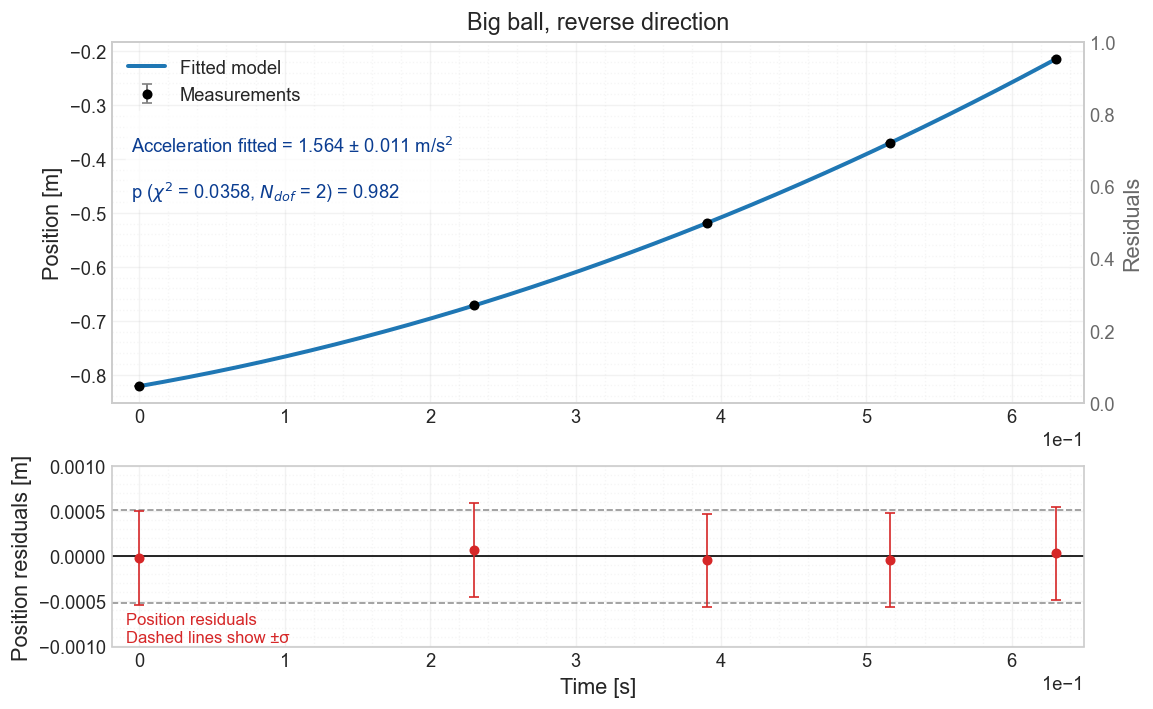

In [42]:
fig, axes, (a, sa), pars, perrs, chi2_val, ndof = plot_iminuit_fit_using_model(
    mfit=mfit_reverse_big,
    t=times_by_experiment[3],
    y=positions,
    model=quadratic_fit,   # your function: p2 is acceleration
    yerr=gate_position_weighted_err,  # or None
    title_top="Big ball, reverse direction",
)
plt.show()

In [43]:
# Alternatively, use the Chi2 regression from External Functions:
cfit_reverse_medium = cost.LeastSquares(times_by_experiment[4], positions, sx, quadratic_fit)

# NOTE: Did you remember to ensure, that all bins had entries in them, i.e. that y>0?

mfit_reverse_medium = Minuit(cfit_reverse_medium, p0=0, p1=0, p2=0)
mfit_reverse_medium.migrad()           # This is where the minimisation is carried out! Put ";" at the end to void output

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 0.05247 (χ²/ndof = 0.0)    │              Nfcn = 72               │
│ EDM = 5.14e-14 (Goal: 0.0002)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ p0   │ -821.4e-3 │  0.5e-3   │            │            │         │         │       │
│ 1 │ p1   │   0.467   │   0.004   │            │            │         │         │       │
│ 2 │ p2   │   1.491   │   0.011   │            │            │         │         │       │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌────┬───────────────────────────────┐
│    │        p0        p1        p2 │
├────┼───────────────────────────────┤
│ p0 │  2.59e-07  -1.27e-6   2.78e-6 │
│ p1 │  -1.27e-6  1.27e-05 -0.037e-3 │
│ p2 │   2.78e-6 -0.037e-3  0.000115 │
└────┴───────────────────────────────┘

In [44]:
chi2_rev = mfit_reverse_medium.fval                     # ChiSquare value
Ndof_rev = len(times_by_experiment[4]) - mfit_reverse_medium.nfit     # Number of (non-empty) bins
Prob_rev = stats.chi2.sf(chi2_rev, Ndof_rev)     # ChiSquare probability given Ndof

print("Chi2 = ",chi2_rev)
print("number DOF = ", Ndof_rev)
print("Prob", Prob_rev)

Chi2 =  0.05246677389317636
number DOF =  2
Prob 0.974107719050924


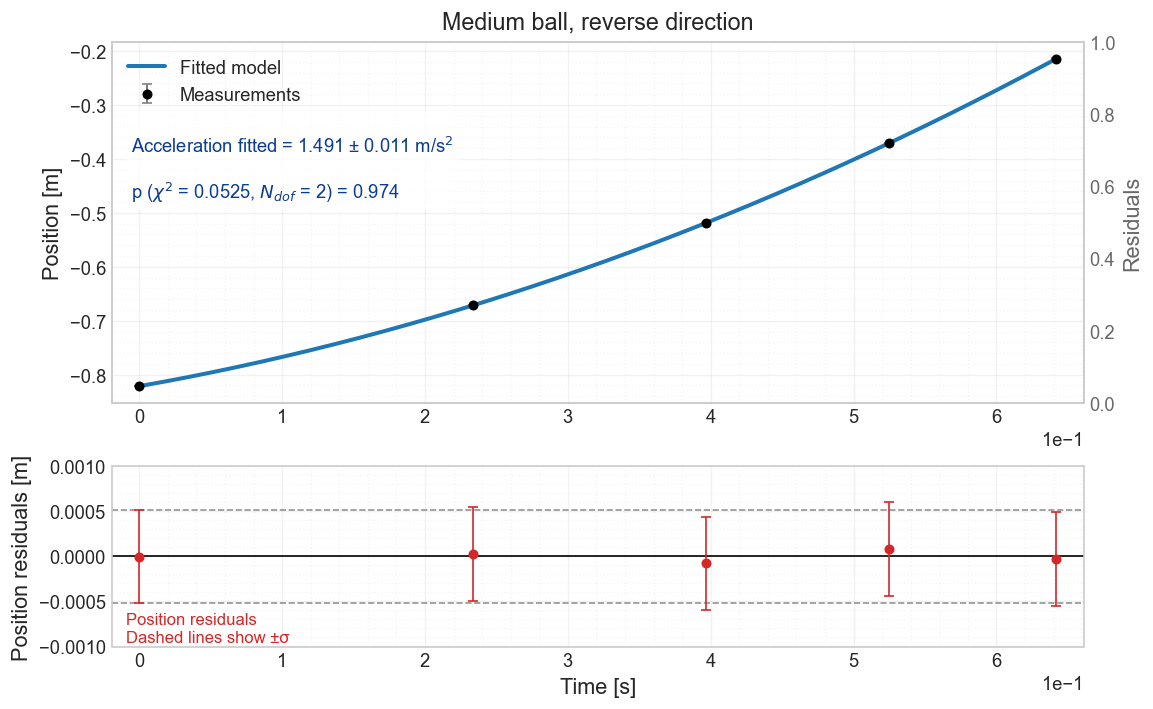

In [45]:
fig, axes, (a, sa), pars, perrs, chi2_val, ndof = plot_iminuit_fit_using_model(
    mfit=mfit_reverse_medium,
    t=times_by_experiment[4],
    y=positions,
    model=quadratic_fit,   # your function: p2 is acceleration
    yerr=gate_position_weighted_err,  # or None
    title_top="Medium ball, reverse direction",
)
plt.show()

In [46]:
# Alternatively, use the Chi2 regression from External Functions:
cfit_reverse_small = cost.LeastSquares(times_by_experiment[5], positions, sx, quadratic_fit)

# NOTE: Did you remember to ensure, that all bins had entries in them, i.e. that y>0?

mfit_reverse_small = Minuit(cfit_reverse_small, p0=0, p1=0, p2=0)
mfit_reverse_small.migrad()           # This is where the minimisation is carried out! Put ";" at the end to void output

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 2.492 (χ²/ndof = 1.2)      │              Nfcn = 72               │
│ EDM = 2.08e-14 (Goal: 0.0002)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ p0   │ -821.2e-3 │  0.5e-3   │            │            │         │         │       │
│ 1 │ p1   │  0.4375   │  0.0034   │            │            │         │         │       │
│ 2 │ p2   │   1.368   │   0.010   │            │            │         │         │       │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌────┬───────────────────────────────┐
│    │        p0        p1        p2 │
├────┼───────────────────────────────┤
│ p0 │  2.59e-07  -1.20e-6   2.51e-6 │
│ p1 │  -1.20e-6  1.15e-05 -0.032e-3 │
│ p2 │   2.51e-6 -0.032e-3  9.44e-05 │
└────┴───────────────────────────────┘

In [47]:
chi2_rev = mfit_reverse_small.fval                     # ChiSquare value
Ndof_rev = len(times_by_experiment[5]) - mfit_reverse_small.nfit     # Number of (non-empty) bins
Prob_rev = stats.chi2.sf(chi2_rev, Ndof_rev)     # ChiSquare probability given Ndof

print("Chi2 = ",chi2_rev)
print("number DOF = ", Ndof_rev)
print("Prob", Prob_rev)

Chi2 =  2.4919153901522773
number DOF =  2
Prob 0.28766528054549184


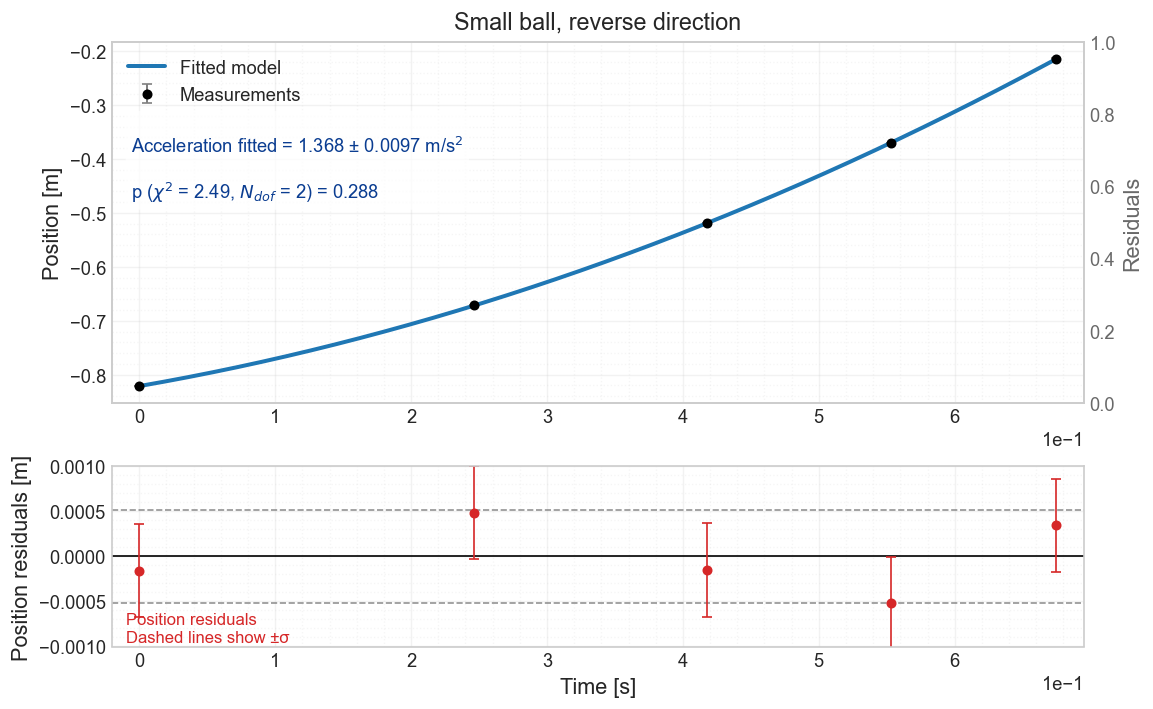

In [48]:
fig, axes, (a, sa), pars, perrs, chi2_val, ndof = plot_iminuit_fit_using_model(
    mfit=mfit_reverse_small,
    t=times_by_experiment[5],
    y=positions,
    model=quadratic_fit,   # your function: p2 is acceleration
    yerr=gate_position_weighted_err,  # or None
    title_top="Small ball, reverse direction",
)
plt.show()

In [49]:
p2_normal_b = mfit_normal_big.values["p2"]
e2_normal_b = mfit_normal_big.errors["p2"]

p2_normal_m = mfit_normal_medium.values["p2"]
e2_normal_m = mfit_normal_medium.errors["p2"]

p2_normal_s = mfit_normal_small.values["p2"]
e2_normal_s = mfit_normal_small.errors["p2"]

p2_reverse_b = mfit_reverse_big.values["p2"]
e2_reverse_b = mfit_reverse_big.errors["p2"]

p2_reverse_m = mfit_reverse_medium.values["p2"]
e2_reverse_m = mfit_normal_medium.errors["p2"]

p2_reverse_s = mfit_reverse_small.values["p2"]
e2_reverse_s = mfit_reverse_small.errors["p2"]

print("acceleration normal big [m*s^-2] = ", p2_normal_b)
print("acceleration normal big error [m*s^-2] = ", e2_normal_b)

print("\nacceleration normal medium [m*s^-2] = ", p2_normal_m)
print("acceleration normal medium error [m*s^-2] = ", e2_normal_m)

print("\nacceleration normal small [m*s^-2] = ", p2_normal_s)
print("acceleration normal small error [m*s^-2] = ", e2_normal_s)

print("\nacceleration reverse big [m*s^-2] = ", p2_reverse_b)
print("acceleration reverse big error [m*s^-2] = ", e2_reverse_b)

print("\nacceleration reverse medium [m*s^-2] = ", p2_reverse_m)
print("acceleration reverse medium error [m*s^-2] = ", e2_reverse_m)

print("\nacceleration reverse small [m*s^-2] = ", p2_reverse_s)
print("acceleration reverse small error [m*s^-2] = ", e2_reverse_s)

acceleration normal big [m*s^-2] =  1.5666329955907985
acceleration normal big error [m*s^-2] =  0.01113374468620341

acceleration normal medium [m*s^-2] =  1.4976948786761914
acceleration normal medium error [m*s^-2] =  0.010742028635584168

acceleration normal small [m*s^-2] =  1.3445352707195541
acceleration normal small error [m*s^-2] =  0.009606060956857043

acceleration reverse big [m*s^-2] =  1.5635756254136366
acceleration reverse big error [m*s^-2] =  0.011115267430996723

acceleration reverse medium [m*s^-2] =  1.4905043001428167
acceleration reverse medium error [m*s^-2] =  0.010742028635584168

acceleration reverse small [m*s^-2] =  1.3680492007391454
acceleration reverse small error [m*s^-2] =  0.009716730698326202


## Calculate delta theta

In [50]:
# Delta theta from goniometer
delta_theta_gonio = np.abs(angle_goniometer_normal_wmean - angle_goniometer_reverse_wmean)/2
delta_theta_gonio_err = np.sqrt(angle_goniometer_normal_werr**2 + angle_goniometer_reverse_werr**2)/2   # This migth not be the right error => It is, I checked!

print(f" Δθ from goniometer= {delta_theta_gonio:.6f}° ± {delta_theta_gonio_err:.6f}°")

 Δθ from goniometer= 0.015000° ± 0.022361°


In [51]:
def delta_theta_each_with_uncertainty(a_norm, a_norm_err,
                                      a_rev, a_rev_err,
                                      theta_deg, theta_err_deg):
    """
    Compute Δθ per element and its 1σ uncertainty using analytic derivatives of:
        Δθ = atan( ((a_norm - a_rev) * sinθ) / ((a_norm + a_rev) * cosθ) )

    Inputs can be scalars or arrays; arrays must be broadcastable to a common shape.

    Parameters
    ----------
    a_norm, a_rev : array-like or scalar
        Accelerations (consistent units).
    a_norm_err, a_rev_err : array-like or scalar
        Per-point 1σ uncertainties for a_norm and a_rev (same units as inputs).
    theta_deg : array-like or scalar
        θ in degrees (per-point or common).
    theta_err_deg : array-like or scalar
        1σ uncertainty on θ in degrees (per-point or common).

    Returns
    -------
    delta_deg : ndarray
        Δθ per element in degrees.
    sigma_delta_deg : ndarray
        1σ uncertainty on Δθ per element in degrees.
    """
    # Cast/broadcast to arrays
    x = np.asarray(a_norm, dtype=float)
    y = np.asarray(a_rev, dtype=float)
    sx = np.asarray(a_norm_err, dtype=float)
    sy = np.asarray(a_rev_err, dtype=float)
    T = np.deg2rad(np.asarray(theta_deg, dtype=float))
    sT = np.deg2rad(np.asarray(theta_err_deg, dtype=float))

    # Core quantities
    N = x - y
    D = x + y

    with np.errstate(divide='ignore', invalid='ignore'):
        A = N / D
        tanT = np.tan(T)
        r = A * tanT
        delta_rad = np.arctan(r)

        # Derivatives
        # A = (x - y)/(x + y)
        dA_dx = 2.0 * y / (D**2)
        dA_dy = -2.0 * x / (D**2)

        # r = A * tan(T)
        dr_dx = dA_dx * tanT
        dr_dy = dA_dy * tanT
        dr_dT = A * (1.0 / np.cos(T))**2  # A * sec^2(T)

        # f = atan(r) -> df/dr = 1/(1 + r^2)
        df_dr = 1.0 / (1.0 + r**2)

        ddelta_dx = df_dr * dr_dx
        ddelta_dy = df_dr * dr_dy
        ddelta_dT = df_dr * dr_dT

        # Uncertainty propagation
        sigma_delta_rad = np.sqrt((ddelta_dx * sx)**2 +
                                  (ddelta_dy * sy)**2 +
                                  (ddelta_dT * sT)**2)

    delta_deg = np.rad2deg(delta_rad)
    sigma_delta_deg = np.rad2deg(sigma_delta_rad)

    # Mark invalid points (e.g., D≈0 or cos(T)≈0) as NaN
    bad = ~np.isfinite(r) | ~np.isfinite(delta_deg) | ~np.isfinite(sigma_delta_deg)
    delta_deg = np.where(bad, np.nan, delta_deg)
    sigma_delta_deg = np.where(bad, np.nan, sigma_delta_deg)

    return delta_deg, sigma_delta_deg

# Example arrays (replace with your real data)
a_norm = np.array([p2_normal_b, p2_normal_m, p2_normal_s])
a_rev  = np.array([p2_reverse_b, p2_reverse_m, p2_reverse_s])

# Per-point 1σ uncertainties (same shape or scalars)
a_norm_err = np.array([e2_normal_b, e2_normal_m, e2_normal_s])
a_rev_err  = np.array([e2_reverse_b, e2_reverse_m, e2_reverse_s])

# θ can be a single value for all points, or an array per point
theta_deg     = angle_trig_overall_wmean        # scalar angle (deg)
theta_err_deg = angle_trig_overall_werr         # scalar 1σ (deg), e.g., your weighted θ uncertainty

# Δθ per element with propagated 1σ uncertainties
delta_each_deg, sigma_each_deg = delta_theta_each_with_uncertainty(
    a_norm, a_norm_err, a_rev, a_rev_err, theta_deg, theta_err_deg
)
for i, (d, s) in enumerate(zip(delta_each_deg, sigma_each_deg), start=1):
    print(f"#{i:02d}: Δθ = {d:.6f}° ± {s:.6f}°")

delta_theta_trig, delta_theta_trig_err = weighted_mean(delta_each_deg[:-1], sigma_each_deg[:-1])
print(f"\n Δθ from trig withour small ball= {delta_theta_trig:.6f}° ± {delta_theta_trig_err:.6f}°")

#01: Δθ = 0.013930° ± 0.071682°
#02: Δθ = 0.034319° ± 0.072507°
#03: Δθ = -0.123631° ± 0.071835°

 Δθ from trig withour small ball= 0.024008° ± 0.050976°


In [52]:
# Chi2
chi2_deltaT = np.sum((delta_each_deg[:-1] - delta_theta_trig)**2/sigma_each_deg[:-1]**2)
chi2_prob_deltaT = stats.chi2.sf(chi2_deltaT, len(delta_each_deg[:-1])-1)
dof_deltaT = len(delta_each_deg[:-1])-1

print("chi2 delta theta trig", chi2_deltaT)
print("chi2 prob delta theta trig ", chi2_prob_deltaT)
print("DOF delta theta trig", dof_deltaT)

chi2 delta theta trig 0.0399900745930231
chi2 prob delta theta trig  0.8414999886633623
DOF delta theta trig 1


In [53]:
# Combine delta theta from trig and goniometer
delta_theta_trig, delta_theta_trig_err
delta_theta_gonio
delta_theta_gonio_err

delta_theta_total, delta_theta_total_err = weighted_mean(np.array([delta_theta_trig, delta_theta_gonio]), np.array([delta_theta_trig_err, delta_theta_gonio_err]))
print(f"\n Δθ total= {delta_theta_total:.6f}° ± {delta_theta_total_err:.6f}°")


 Δθ total= 0.016454° ± 0.020477°


## Calculate g and the error

In [54]:
def calc_g_goniometer(acc, acc_err, theta, theta_err, d_ball, d_ball_err, d_rail, d_rail_err):      # theta, theta_err must include delta theta, if the angle is from trig
    g = acc/np.sin(np.radians(theta)) * (1 + 2/5 * d_ball**2/(d_ball**2 - d_rail**2))       # we asssume, that theta is in deg
    g_err = 1
    return g, g_err

## Using SymPy

In [55]:
from IPython.core.display import Latex

def lprint(*args,**kwargs):
    """Pretty print arguments as LaTeX using IPython display system 
    
    Parameters
    ----------
    args : tuple 
        What to print (in LaTeX math mode)
    kwargs : dict 
        optional keywords to pass to `display` 
    """
    display(Latex('$$'+' '.join(args)+'$$'),**kwargs)

In [56]:
# Imports
from sympy import symbols, sin, sqrt, diff, Eq, latex
from IPython.display import display, Latex

def lprint(*args, **kwargs):
    """Pretty print arguments as LaTeX using IPython display system."""
    display(Latex('$$' + ' '.join(args) + '$$'), **kwargs)

# Symbols
g, a, theta, Delta_theta, d_ball, d_rail = symbols('g a theta Delta_theta d_ball d_rail', real=True)
sigma_g, sigma_a, sigma_theta, sigma_Delta_theta, sigma_d_ball, sigma_d_rail = symbols(
    'sigma_g sigma_a sigma_theta sigma_Delta_theta sigma_d_ball sigma_d_rail', positive=True
)

# Define g
geom = 1 + (2/5) * (d_ball**2) / (d_ball**2 - d_rail**2)
g_expr = a / sin(theta + Delta_theta) * geom

# Partials
dg_da      = diff(g_expr, a)
dg_dtheta  = diff(g_expr, theta)
dg_dDtheta = diff(g_expr, Delta_theta)
dg_ddball  = diff(g_expr, d_ball)
dg_ddrail  = diff(g_expr, d_rail)

# Uncertainty propagation
sigma_g_expr = sqrt(
    (dg_da     * sigma_a)**2 +
    (dg_dtheta * sigma_theta)**2 +
    (dg_dDtheta* sigma_Delta_theta)**2 +
    (dg_ddball * sigma_d_ball)**2 +
    (dg_ddrail * sigma_d_rail)**2
)



# Symbolic partial derivatives of g w.r.t inputs
dg_da          = diff(g_expr, a)
dg_dtheta      = diff(g_expr, theta)
dg_dDeltaTheta = diff(g_expr, Delta_theta)
dg_ddball      = diff(g_expr, d_ball)
dg_ddrail      = diff(g_expr, d_rail)

# Squared contribution terms (each is a variance component)
C_a          = (dg_da          * sigma_a           )**2
C_theta      = (dg_dtheta      * sigma_theta       )**2
C_DeltaTheta = (dg_dDeltaTheta * sigma_Delta_theta )**2
C_dball      = (dg_ddball      * sigma_d_ball      )**2
C_drail      = (dg_ddrail      * sigma_d_rail      )**2

# Convenience dicts for iteration/printing
contrib_terms = {
    'a': C_a,
    'theta': C_theta,
    'Delta_theta': C_DeltaTheta,
    'd_ball': C_dball,
    'd_rail': C_drail
}

partials = {
    'a': dg_da,
    'theta': dg_dtheta,
    'Delta_theta': dg_dDeltaTheta,
    'd_ball': dg_ddball,
    'd_rail': dg_ddrail
}

def print_contrib_breakdown(header, v_g, vd_g, contrib_values, sensitivities):
    """
    Pretty-prints per-variable contributions.
    contrib_values: dict name -> C_x (squared contribution, absolute)
    sensitivities:  dict name -> dg/dx at the evaluation point
    """
    label = {
        'a': 'acceleration a',
        'theta': 'angle θ',
        'Delta_theta': 'Δθ',
        'd_ball': 'd_ball',
        'd_rail': 'd_rail',
    }
    sigma_g2 = float(vd_g)**2
    print(f"\n{header}")


# Outputs (symbolic)
lprint(latex(Eq(symbols('g'), g_expr)))
lprint(latex(Eq(symbols('sigma_g'), sigma_g_expr)))


<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

In [57]:
latex(Eq(symbols('sigma_g'), sigma_g_expr))

'\\sigma_{g} = \\sqrt{\\frac{0.64 a^{2} d_{ball}^{4} d_{rail}^{2} \\sigma_{d rail}^{2}}{\\left(d_{ball}^{2} - d_{rail}^{2}\\right)^{4} \\sin^{2}{\\left(\\Delta_{\\theta} + \\theta \\right)}} + \\frac{a^{2} \\sigma_{\\Delta \\theta}^{2} \\left(\\frac{0.4 d_{ball}^{2}}{d_{ball}^{2} - d_{rail}^{2}} + 1\\right)^{2} \\cos^{2}{\\left(\\Delta_{\\theta} + \\theta \\right)}}{\\sin^{4}{\\left(\\Delta_{\\theta} + \\theta \\right)}} + \\frac{a^{2} \\sigma_{d ball}^{2} \\left(- \\frac{0.8 d_{ball}^{3}}{\\left(d_{ball}^{2} - d_{rail}^{2}\\right)^{2}} + \\frac{0.8 d_{ball}}{d_{ball}^{2} - d_{rail}^{2}}\\right)^{2}}{\\sin^{2}{\\left(\\Delta_{\\theta} + \\theta \\right)}} + \\frac{a^{2} \\sigma_{\\theta}^{2} \\left(\\frac{0.4 d_{ball}^{2}}{d_{ball}^{2} - d_{rail}^{2}} + 1\\right)^{2} \\cos^{2}{\\left(\\Delta_{\\theta} + \\theta \\right)}}{\\sin^{4}{\\left(\\Delta_{\\theta} + \\theta \\right)}} + \\frac{\\sigma_{a}^{2} \\left(\\frac{0.4 d_{ball}^{2}}{d_{ball}^{2} - d_{rail}^{2}} + 1\\right)^{2}}{\\sin^{

In [58]:
# for trig angle with trid delta theta
ball = np.array([ball_l_weighted, ball_m_weighted, ball_s_weighted])
ball_err = np.array([ball_l_weighted_err, ball_m_weighted_err, ball_s_weighted_err])

rail = rail_distances_weighted
rail_err = rail_distances_weighted_err

trig_theta = np.radians(angle_trig_overall_wmean)
trig_theta_err = np.radians(angle_trig_overall_werr)

trig_delta_theta = np.radians(delta_theta_trig)
trig_delta_theta_err = np.radians(delta_theta_trig_err)

acceleration_normal = np.array([p2_normal_b, p2_normal_m, p2_normal_s])
acceleration_normal_err = np.array([e2_normal_b, e2_normal_m, e2_normal_s])

acceleration_reverse = np.array([p2_reverse_b, p2_reverse_m, p2_reverse_s])
acceleration_reverse_err = np.array([e2_reverse_b, e2_reverse_m, e2_reverse_s])

# Symbolic partials and squared-contribution terms
dg_da          = diff(g_expr, a)
dg_dtheta      = diff(g_expr, theta)
dg_dDeltaTheta = diff(g_expr, Delta_theta)
dg_ddball      = diff(g_expr, d_ball)
dg_ddrail      = diff(g_expr, d_rail)

C_a          = (dg_da          * sigma_a           )**2
C_theta      = (dg_dtheta      * sigma_theta       )**2
C_DeltaTheta = (dg_dDeltaTheta * sigma_Delta_theta )**2
C_dball      = (dg_ddball      * sigma_d_ball      )**2
C_drail      = (dg_ddrail      * sigma_d_rail      )**2

contrib_terms = {
    'a': C_a,
    'theta': C_theta,
    'Delta_theta': C_DeltaTheta,
    'd_ball': C_dball,
    'd_rail': C_drail
}

partials = {
    'a': dg_da,
    'theta': dg_dtheta,
    'Delta_theta': dg_dDeltaTheta,
    'd_ball': dg_ddball,
    'd_rail': dg_ddrail
}

def print_contrib_breakdown(header, v_g, vd_g, contrib_values, sensitivities):
    """
    Prints per-variable contributions:
      - C_x (absolute squared contribution, same units as g^2)
      - percentage of sigma_g^2
      - sensitivity ∂g/∂x
    """
    var_label = {
        'a': 'acceleration a',
        'theta': 'angle θ',
        'Delta_theta': 'Δθ',
        'd_ball': 'd_ball',
        'd_rail': 'd_rail',
    }
    sigma_g2 = float(vd_g)**2
    print(f"\n{header}")
    print(f"  g = {float(v_g):.6g} ± {float(vd_g):.3g}")
    print("  Error budget (C_x and % of σ_g²), with sensitivities:")
    for k in ['a', 'theta', 'Delta_theta', 'd_ball', 'd_rail']:
        Ck = float(contrib_values[k])
        frac = Ck / sigma_g2 if sigma_g2 > 0 else float('nan')
        sens = float(sensitivities[k])
        print(f"    {var_label[k]:>12}:  C_{k} = {Ck:.3g}  ({100*frac:5.1f}%)   ∂g/∂{k} = {sens:.3g}")

# Outputs arrays
gravitational_acceleration_normal = np.array([], dtype=float)
gravitational_acceleration_normal_err = np.array([], dtype=float)

gravitational_acceleration_reverse = np.array([], dtype=float)
gravitational_acceleration_reverse_err = np.array([], dtype=float)

# Normal direction loop with error-budget printing
for i in range(len(ball)):
    v_a,   vd_a   = acceleration_normal[i], acceleration_normal_err[i]
    v_theta, vd_theta = trig_theta, trig_theta_err
    v_dtheta, vd_dtheta = trig_delta_theta, trig_delta_theta_err
    v_ball, vd_ball = ball[i], ball_err[i]
    v_rail, vd_rail = rail, rail_err

    # Coerce to float
    v_a      = float(v_a);      vd_a      = float(vd_a)
    v_theta  = float(v_theta);  vd_theta  = float(vd_theta)
    v_dtheta = float(v_dtheta); vd_dtheta = float(vd_dtheta)
    v_ball   = float(v_ball);   vd_ball   = float(vd_ball)
    v_rail   = float(v_rail);   vd_rail   = float(vd_rail)

    subs_vals = {a: v_a, theta: v_theta, Delta_theta: v_dtheta, d_ball: v_ball, d_rail: v_rail}
    subs_sigmas = {sigma_a: vd_a, sigma_theta: vd_theta, sigma_Delta_theta: vd_dtheta,
                   sigma_d_ball: vd_ball, sigma_d_rail: vd_rail}

    # Evaluate g and sigma_g (as floats)
    v_g  = float(g_expr.subs(subs_vals).evalf())
    vd_g = float(sigma_g_expr.subs({**subs_vals, **subs_sigmas}).evalf())

    # Evaluate squared contributions and sensitivities
    C_vals = {name: float(expr.subs({**subs_vals, **subs_sigmas}).evalf())
              for name, expr in contrib_terms.items()}
    dgs    = {name: float(expr.subs(subs_vals).evalf())
              for name, expr in partials.items()}

    # Append
    gravitational_acceleration_normal = np.append(gravitational_acceleration_normal, v_g)
    gravitational_acceleration_normal_err = np.append(gravitational_acceleration_normal_err, vd_g)

    # Print breakdown
    print_contrib_breakdown(
        header=f"[Normal] measurement i={i}",
        v_g=v_g, vd_g=vd_g, contrib_values=C_vals, sensitivities=dgs
    )

# Reverse direction loop with error-budget printing
for i in range(len(ball)):
    v_a,   vd_a   = acceleration_reverse[i], acceleration_reverse_err[i]
    v_theta, vd_theta = trig_theta, trig_theta_err
    v_dtheta, vd_dtheta = -trig_delta_theta, trig_delta_theta_err  # sign flip
    v_ball, vd_ball = ball[i], ball_err[i]
    v_rail, vd_rail = rail, rail_err

    # Coerce to float
    v_a      = float(v_a);      vd_a      = float(vd_a)
    v_theta  = float(v_theta);  vd_theta  = float(vd_theta)
    v_dtheta = float(v_dtheta); vd_dtheta = float(vd_dtheta)
    v_ball   = float(v_ball);   vd_ball   = float(vd_ball)
    v_rail   = float(v_rail);   vd_rail   = float(vd_rail)

    subs_vals = {a: v_a, theta: v_theta, Delta_theta: v_dtheta, d_ball: v_ball, d_rail: v_rail}
    subs_sigmas = {sigma_a: vd_a, sigma_theta: vd_theta, sigma_Delta_theta: vd_dtheta,
                   sigma_d_ball: vd_ball, sigma_d_rail: vd_rail}

    v_g  = float(g_expr.subs(subs_vals).evalf())
    vd_g = float(sigma_g_expr.subs({**subs_vals, **subs_sigmas}).evalf())

    C_vals = {name: float(expr.subs({**subs_vals, **subs_sigmas}).evalf())
              for name, expr in contrib_terms.items()}
    dgs    = {name: float(expr.subs(subs_vals).evalf())
              for name, expr in partials.items()}

    gravitational_acceleration_reverse = np.append(gravitational_acceleration_reverse, v_g)
    gravitational_acceleration_reverse_err = np.append(gravitational_acceleration_reverse_err, vd_g)

    print_contrib_breakdown(
        header=f"[Reverse] measurement i={i}",
        v_g=v_g, vd_g=vd_g, contrib_values=C_vals, sensitivities=dgs
    )

# Summary prints
print("\nacceleration normal with trig angle = ", gravitational_acceleration_normal)
print("acceleration normal with trig angle error = ", gravitational_acceleration_normal_err)

print("acceleration reverse with trig angle = ", gravitational_acceleration_reverse)
print("acceleration reverse with trig angle error = ", gravitational_acceleration_reverse_err)

# Ensure dtype=float for downstream calcs
gravitational_acceleration_normal      = np.asarray(gravitational_acceleration_normal, dtype=float)
gravitational_acceleration_normal_err  = np.asarray(gravitational_acceleration_normal_err, dtype=float)
gravitational_acceleration_reverse     = np.asarray(gravitational_acceleration_reverse, dtype=float)
gravitational_acceleration_reverse_err = np.asarray(gravitational_acceleration_reverse_err, dtype=float)

# combined means from only big and medium ball
gravitational_acceleration_normal_combined_trig = (gravitational_acceleration_normal[0] + gravitational_acceleration_normal[1])/2
gravitational_acceleration_normal_err_combined_trig = 1/2 * (gravitational_acceleration_normal_err[0] + gravitational_acceleration_normal_err[1])

gravitational_acceleration_reverse_combined_trig = (gravitational_acceleration_reverse[0] + gravitational_acceleration_reverse[1])/2
gravitational_acceleration_reverse_err_combined_trig = 1/2 * (gravitational_acceleration_reverse_err[0] + gravitational_acceleration_reverse_err[1])

print("\nOnly the g from the big and medium ball is used to calculate a combined g")
print("gravitational acceleration normal with trig angle (+Δθ) combined = ", gravitational_acceleration_normal_combined_trig)
print("gravitational acceleration normal with trig angle error combined = ", gravitational_acceleration_normal_err_combined_trig)

print("gravitational acceleration reverse with trig angle (-Δθ) combined = ", gravitational_acceleration_reverse_combined_trig)
print("gravitational acceleration reverse with trig angle error combined = ", gravitational_acceleration_reverse_err_combined_trig)


[Normal] measurement i=0
  g = 9.54017 ± 0.0766
  Error budget (C_x and % of σ_g²), with sensitivities:
    acceleration a:  C_a = 0.0046  ( 78.4%)   ∂g/∂a = 6.09
         angle θ:  C_theta = 2.33e-05  (  0.4%)   ∂g/∂theta = -38.3
              Δθ:  C_Delta_theta = 0.00116  ( 19.8%)   ∂g/∂Delta_theta = -38.3
          d_ball:  C_d_ball = 1.14e-05  (  0.2%)   ∂g/∂d_ball = -75.6
          d_rail:  C_d_rail = 7.38e-05  (  1.3%)   ∂g/∂d_rail = 192

[Normal] measurement i=1
  g = 9.46201 ± 0.078
  Error budget (C_x and % of σ_g²), with sensitivities:
    acceleration a:  C_a = 0.00461  ( 75.6%)   ∂g/∂a = 6.32
         angle θ:  C_theta = 2.29e-05  (  0.4%)   ∂g/∂theta = -37.9
              Δθ:  C_Delta_theta = 0.00114  ( 18.7%)   ∂g/∂Delta_theta = -37.9
          d_ball:  C_d_ball = 6.27e-05  (  1.0%)   ∂g/∂d_ball = -177
          d_rail:  C_d_rail = 0.000258  (  4.2%)   ∂g/∂d_rail = 359

[Normal] measurement i=2
  g = 8.97106 ± 0.0788
  Error budget (C_x and % of σ_g²), with sensitivities

In [59]:
# for goniometer angle with no delta theta
ball = np.array([ball_l_weighted, ball_m_weighted, ball_s_weighted])
ball_err = np.array([ball_l_weighted_err, ball_m_weighted_err, ball_s_weighted_err])

rail = rail_distances_weighted
rail_err = rail_distances_weighted_err

goniometer_theta_normal  = np.radians(angle_goniometer_normal_wmean)
goniometer_theta_normal_err = np.radians(angle_goniometer_normal_werr)

goniometer_theta_reverse = np.radians(angle_goniometer_reverse_wmean)
goniometer_theta_reverse_err = np.radians(angle_goniometer_reverse_werr)

acceleration_normal = np.array([p2_normal_b, p2_normal_m, p2_normal_s])
acceleration_normal_err = np.array([e2_normal_b, e2_normal_m, e2_normal_s])

acceleration_reverse = np.array([p2_reverse_b, p2_reverse_m, p2_reverse_s])
acceleration_reverse_err = np.array([e2_reverse_b, e2_reverse_m, e2_reverse_s])

# Symbolic partials and squared-contribution terms
dg_da          = diff(g_expr, a)
dg_dtheta      = diff(g_expr, theta)
dg_dDeltaTheta = diff(g_expr, Delta_theta)
dg_ddball      = diff(g_expr, d_ball)
dg_ddrail      = diff(g_expr, d_rail)

C_a          = (dg_da          * sigma_a           )**2
C_theta      = (dg_dtheta      * sigma_theta       )**2
C_DeltaTheta = (dg_dDeltaTheta * sigma_Delta_theta )**2
C_dball      = (dg_ddball      * sigma_d_ball      )**2
C_drail      = (dg_ddrail      * sigma_d_rail      )**2

contrib_terms = {
    'a': C_a,
    'theta': C_theta,
    'Delta_theta': C_DeltaTheta,
    'd_ball': C_dball,
    'd_rail': C_drail
}

partials = {
    'a': dg_da,
    'theta': dg_dtheta,
    'Delta_theta': dg_dDeltaTheta,
    'd_ball': dg_ddball,
    'd_rail': dg_ddrail
}

def print_contrib_breakdown(header, v_g, vd_g, contrib_values, sensitivities):
    """
    Prints per-variable contributions:
      - C_x (absolute squared contribution, units of g^2)
      - percentage of sigma_g^2
      - sensitivity ∂g/∂x
    """
    var_label = {
        'a': 'acceleration a',
        'theta': 'angle θ',
        'Delta_theta': 'Δθ',
        'd_ball': 'd_ball',
        'd_rail': 'd_rail',
    }
    sigma_g2 = float(vd_g)**2
    print(f"\n{header}")
    print(f"  g = {float(v_g):.6g} ± {float(vd_g):.3g}")
    print("  Error budget (C_x and % of σ_g²), with sensitivities:")
    for k in ['a', 'theta', 'Delta_theta', 'd_ball', 'd_rail']:
        Ck = float(contrib_values[k])
        frac = Ck / sigma_g2 if sigma_g2 > 0 else float('nan')
        sens = float(sensitivities[k])
        print(f"    {var_label[k]:>12}:  C_{k} = {Ck:.3g}  ({100*frac:5.1f}%)   ∂g/∂{k} = {sens:.3g}")

# Outputs arrays
gravitational_acceleration_normal = np.array([], dtype=float)
gravitational_acceleration_normal_err = np.array([], dtype=float)
gravitational_acceleration_reverse = np.array([], dtype=float)
gravitational_acceleration_reverse_err = np.array([], dtype=float)

# Normal direction loop (uses goniometer θ_normal)
for i in range(len(ball)):
    v_a,   vd_a   = acceleration_normal[i], acceleration_normal_err[i]
    v_theta, vd_theta = goniometer_theta_normal, goniometer_theta_normal_err
    v_dtheta, vd_dtheta = 0, 0
    v_ball, vd_ball = ball[i], ball_err[i]
    v_rail, vd_rail = rail, rail_err

    # Coerce to float
    v_a      = float(v_a);      vd_a      = float(vd_a)
    v_theta  = float(v_theta);  vd_theta  = float(vd_theta)
    v_dtheta = float(v_dtheta); vd_dtheta = float(vd_dtheta)
    v_ball   = float(v_ball);   vd_ball   = float(vd_ball)
    v_rail   = float(v_rail);   vd_rail   = float(vd_rail)

    subs_vals = {a: v_a, theta: v_theta, Delta_theta: v_dtheta, d_ball: v_ball, d_rail: v_rail}
    subs_sigmas = {sigma_a: vd_a, sigma_theta: vd_theta, sigma_Delta_theta: vd_dtheta,
                   sigma_d_ball: vd_ball, sigma_d_rail: vd_rail}

    # Evaluate g and sigma_g
    v_g  = float(g_expr.subs(subs_vals).evalf())
    vd_g = float(sigma_g_expr.subs({**subs_vals, **subs_sigmas}).evalf())

    # Contributions and sensitivities
    C_vals = {name: float(expr.subs({**subs_vals, **subs_sigmas}).evalf())
              for name, expr in contrib_terms.items()}
    dgs    = {name: float(expr.subs(subs_vals).evalf())
              for name, expr in partials.items()}

    # Append and print
    gravitational_acceleration_normal = np.append(gravitational_acceleration_normal, v_g)
    gravitational_acceleration_normal_err = np.append(gravitational_acceleration_normal_err, vd_g)

    print_contrib_breakdown(
        header=f"[Normal (goniometer θ)] measurement i={i}",
        v_g=v_g, vd_g=vd_g, contrib_values=C_vals, sensitivities=dgs
    )

# Reverse direction loop (uses goniometer θ_reverse)
for i in range(len(ball)):
    v_a,   vd_a   = acceleration_reverse[i], acceleration_reverse_err[i]
    v_theta, vd_theta = goniometer_theta_reverse, goniometer_theta_reverse_err
    v_dtheta, vd_dtheta = 0, 0
    v_ball, vd_ball = ball[i], ball_err[i]
    v_rail, vd_rail = rail, rail_err

    # Coerce to float
    v_a      = float(v_a);      vd_a      = float(vd_a)
    v_theta  = float(v_theta);  vd_theta  = float(vd_theta)
    v_dtheta = float(v_dtheta); vd_dtheta = float(vd_dtheta)
    v_ball   = float(v_ball);   vd_ball   = float(vd_ball)
    v_rail   = float(v_rail);   vd_rail   = float(vd_rail)

    subs_vals = {a: v_a, theta: v_theta, Delta_theta: v_dtheta, d_ball: v_ball, d_rail: v_rail}
    subs_sigmas = {sigma_a: vd_a, sigma_theta: vd_theta, sigma_Delta_theta: vd_dtheta,
                   sigma_d_ball: vd_ball, sigma_d_rail: vd_rail}

    v_g  = float(g_expr.subs(subs_vals).evalf())
    vd_g = float(sigma_g_expr.subs({**subs_vals, **subs_sigmas}).evalf())

    C_vals = {name: float(expr.subs({**subs_vals, **subs_sigmas}).evalf())
              for name, expr in contrib_terms.items()}
    dgs    = {name: float(expr.subs(subs_vals).evalf())
              for name, expr in partials.items()}

    gravitational_acceleration_reverse = np.append(gravitational_acceleration_reverse, v_g)
    gravitational_acceleration_reverse_err = np.append(gravitational_acceleration_reverse_err, vd_g)

    print_contrib_breakdown(
        header=f"[Reverse (goniometer θ)] measurement i={i}",
        v_g=v_g, vd_g=vd_g, contrib_values=C_vals, sensitivities=dgs
    )

# Summary prints
print("\ngravitational acceleration normal with goniometer angle = ", gravitational_acceleration_normal)
print("gravitational acceleration normal with goniometer angle error = ", gravitational_acceleration_normal_err)

print("gravitational acceleration reverse with goniometer angle = ", gravitational_acceleration_reverse)
print("gravitational acceleration reverse with goniometer angle error = ", gravitational_acceleration_reverse_err)

# Ensure dtype=float for downstream calcs
gravitational_acceleration_normal      = np.asarray(gravitational_acceleration_normal, dtype=float)
gravitational_acceleration_normal_err  = np.asarray(gravitational_acceleration_normal_err, dtype=float)
gravitational_acceleration_reverse     = np.asarray(gravitational_acceleration_reverse, dtype=float)
gravitational_acceleration_reverse_err = np.asarray(gravitational_acceleration_reverse_err, dtype=float)

# combined means from only big and medium ball
gravitational_acceleration_normal_combined_goniometer = (gravitational_acceleration_normal[0] + gravitational_acceleration_normal[1])/2
gravitational_acceleration_normal_err_combined_goniometer = 1/2 * (gravitational_acceleration_normal_err[0] + gravitational_acceleration_normal_err[1])

gravitational_acceleration_reverse_combined_goniometer = (gravitational_acceleration_reverse[0] + gravitational_acceleration_reverse[1])/2
gravitational_acceleration_reverse_err_combined_goniometer = 1/2 * (gravitational_acceleration_reverse_err[0]+ gravitational_acceleration_reverse_err[1])

print("\nOnly the g from the big and medium ball is used to calculate a combined g")
print("gravitational acceleration normal with goniometer angle combined = ", gravitational_acceleration_normal_combined_goniometer)
print("gravitational acceleration normal with goniometer angle error combined = ", gravitational_acceleration_normal_err_combined_goniometer)

print("gravitational acceleration reverse with goniometer angle combined = ", gravitational_acceleration_reverse_combined_goniometer)
print("gravitational acceleration reverse with goniometer angle error combined = ", gravitational_acceleration_reverse_err_combined_goniometer)


[Normal (goniometer θ)] measurement i=0
  g = 9.55495 ± 0.0717
  Error budget (C_x and % of σ_g²), with sensitivities:
    acceleration a:  C_a = 0.00461  ( 89.6%)   ∂g/∂a = 6.1
         angle θ:  C_theta = 0.000449  (  8.7%)   ∂g/∂theta = -38.4
              Δθ:  C_Delta_theta = 0  (  0.0%)   ∂g/∂Delta_theta = -38.4
          d_ball:  C_d_ball = 1.15e-05  (  0.2%)   ∂g/∂d_ball = -75.7
          d_rail:  C_d_rail = 7.4e-05  (  1.4%)   ∂g/∂d_rail = 192

[Normal (goniometer θ)] measurement i=1
  g = 9.47667 ± 0.0734
  Error budget (C_x and % of σ_g²), with sensitivities:
    acceleration a:  C_a = 0.00462  ( 85.8%)   ∂g/∂a = 6.33
         angle θ:  C_theta = 0.000441  (  8.2%)   ∂g/∂theta = -38.1
              Δθ:  C_Delta_theta = 0  (  0.0%)   ∂g/∂Delta_theta = -38.1
          d_ball:  C_d_ball = 6.29e-05  (  1.2%)   ∂g/∂d_ball = -177
          d_rail:  C_d_rail = 0.000259  (  4.8%)   ∂g/∂d_rail = 360

[Normal (goniometer θ)] measurement i=2
  g = 8.98496 ± 0.0747
  Error budget (C_x a

## Compare trig and goniometer

In [60]:
print("gravitational acceleration normal with trig angle (+Δθ) combined = ", gravitational_acceleration_normal_combined_trig)
print("gravitational acceleration normal with trig angle error combined = ", gravitational_acceleration_normal_err_combined_trig)

print("\ngravitational acceleration reverse with trig angle (-Δθ) combined = ", gravitational_acceleration_reverse_combined_trig)
print("gravitational acceleration reverse with trig angle error combined = ", gravitational_acceleration_reverse_err_combined_trig)

print("\n\ngravitational acceleration normal with goniometer angle combined = ", gravitational_acceleration_normal_combined_goniometer)
print("gravitational acceleration normal with goniometer angle error combined = ", gravitational_acceleration_normal_err_combined_goniometer)

print("\ngravitational acceleration reverse with goniometer angle combined = ", gravitational_acceleration_reverse_combined_goniometer)
print("gravitational acceleration reverse with goniometer angle error combined = ", gravitational_acceleration_reverse_err_combined_goniometer)

gravitational acceleration normal with trig angle (+Δθ) combined =  9.501090361830688
gravitational acceleration normal with trig angle error combined =  0.07730358897747922

gravitational acceleration reverse with trig angle (-Δθ) combined =  9.501000462073787
gravitational acceleration reverse with trig angle error combined =  0.07750670188688533


gravitational acceleration normal with goniometer angle combined =  9.515811339059155
gravitational acceleration normal with goniometer angle error combined =  0.07254964899569707

gravitational acceleration reverse with goniometer angle combined =  9.503727852320795
gravitational acceleration reverse with goniometer angle error combined =  0.07263056303705076


Overall gravitational acceleration

In [61]:
gravitational_acceleration_total_combined = (gravitational_acceleration_normal_combined_trig + gravitational_acceleration_reverse_combined_trig + gravitational_acceleration_normal_combined_goniometer + gravitational_acceleration_reverse_combined_goniometer)/4
gravitational_acceleration_total_err_combined = 1/4 * (gravitational_acceleration_normal_err_combined_trig + gravitational_acceleration_reverse_err_combined_trig + gravitational_acceleration_normal_err_combined_goniometer + gravitational_acceleration_reverse_err_combined_goniometer)

print("gravitational acceleration total = ", gravitational_acceleration_total_combined)
print("gravitational acceleration err total = ", gravitational_acceleration_total_err_combined)

gravitational acceleration total =  9.505407503821106
gravitational acceleration err total =  0.0749976257242781


In [62]:
# Chi2
g_values = np.array([gravitational_acceleration_normal_combined_trig, gravitational_acceleration_reverse_combined_trig, gravitational_acceleration_normal_combined_goniometer, gravitational_acceleration_reverse_combined_goniometer])
g_err = np.array([gravitational_acceleration_normal_err_combined_trig, gravitational_acceleration_reverse_err_combined_trig, gravitational_acceleration_normal_err_combined_goniometer, gravitational_acceleration_reverse_err_combined_goniometer])

chi2_g = np.sum((gravitational_acceleration_total_combined - g_values)**2/g_err**2)
chi2_prob_g = stats.chi2.sf(chi2_g, len(g_values)-1)
dof_g = len(g_values)-1

print("chi2 g = ", chi2_g)
print("chi2 prob g = ", chi2_prob_g)
print("DOF g = ", dof_g)

chi2 g =  0.027451139327846725
chi2 prob g =  0.9988002642212911
DOF g =  3
